# Objectif 

Modélisation de la propagation pour les émissions de la séquence 144. 

Données utilisées : 

* Bathymétrie : GEBCO 2021
* SSP 

In [1]:
import os
import sys
import arlpy
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd 
from sklearn import manifold
from time import time

# project_root = "/home/program/ubf_tools"        # Linux TIM
project_root = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd"  # Windows BAPTISTE
sys.path.append(project_root)

import source.global_constants as g
from publication.publication_figure import PubFigure, LargeFigure, SmallFigure
from propa.ideal_waveguide import (
    psi,
    psi_normalised,
    h,
    field,
    plot_tl,
    nb_propagating_modes,
    print_arrivals,
)
from publication.publication_figure import (
    PubFigure,
    LargeFigure,
    color,
    set_subfigures_abc_labels,
)
from propa.rtf.rtf_utils import D_hermitian_angle_fast, D_euclidian


from real_data_analysis.fiberscope_groix.src.fiberscope_groix_manager import (
    # ActiveFiberscopeManager,
    # PassiveFiberscopeManager,
    BandFilter,
)

from real_data_analysis.fiberscope_groix.src.localisation.rtf.rtf_mfp import (
    RTF_MFP_Processor,
)
from misc import progression_bar
from real_data_analysis.fiberscope_groix.src.localisation.rtf.sensibility.sensibility_study_utils import *

from propa.kraken_toolbox.src.kraken_testcase import (
    KrakenTestCase,
    DomainProperties,
    SourceProperties,
    ReceiverProperties,
    KrakenProperties,
)
from propa.kraken_toolbox.src.kraken_env import (
    KrakenTopHalfspace,
    KrakenMedium,
    KrakenBottomHalfspace,
    KrakenAttenuation,
    KrakenField,
    Bathymetry,
)
from propa.kraken_toolbox.src.kraken_manager import KrakenManager
from propa.kraken_toolbox.plot_utils import plotshd, plotmode, plotmode_several_freqs
from propa.kraken_toolbox.utils import default_nb_rcv_z
from signals.AcousticComponent import AcousticSource
from source.signal_generator import SignalGenerator
from source.ssp_profiles import SSPProfile
from misc import mult_along_axis

# from get_data.cmems import load_data_from_cmems as cmems
from get_data.bathymetry import bathy_profile_extraction as bpe
from cst import N_CORES

pfig = PubFigure()
# print(project_root)

In [2]:
print(project_root)
root_groix_data = os.path.join(project_root, "data", "fiberscope_groix_oct_2025")
root_groix_wav = os.path.join(root_groix_data, "wav")
root_groix_metadata = os.path.join(root_groix_data, "metadata")

root_folder = os.path.join(project_root, "real_data_analysis", "fiberscope_groix")
data_folder = os.path.join(root_folder, "data")
img_folder = os.path.join(root_folder, "img")

sensibility_img_folder = os.path.join(img_folder, "rtf_mfp", "sensibility")

folder_root = os.path.join(project_root, "propa", "rtf", "rtf_estimation", "xp_fiberscope_groix")
tc_root_dir = os.path.join(project_root, "propa", "kraken_toolbox", "testcases")
img_folder_path = os.path.join(folder_root, "img")
data_folder_path = os.path.join(folder_root, "data")

if not os.path.exists(img_folder_path):
    os.makedirs(img_folder_path)
if not os.path.exists(data_folder_path):
    os.makedirs(data_folder_path)


input_data_root = os.path.join(project_root, "data")
bathy_fpath = os.path.join(input_data_root, "bathy", "GEBCO_2021_sub_ice_topo.nc")


C:\Users\baptiste.menetrier\Desktop\devPy\phd


In [3]:
from misc import cast_matrix_to_target_shape
def get_bootstrap_dist(ds_, test_replica_id, estimator="deconv", dist_type="hermitian_angle"):
    # Select one replica_id to compare using bootstrap
    test_replica = ds_.sel(replica_id=test_replica_id)
    # Remove from the rest of the features for bootstraping
    # bootstrap_replica = ds.drop_sel(replica_id=test_replica_id)
    bootstrap_replica = ds_

    if estimator == "deconv":
        # Test RTF
        test_replica_rtf = test_replica.rtf_amp_deconv * np.exp(
            1j * test_replica.rtf_phase_deconv
        )

        # Other RTFs
        bootstrap_replica_rtfs = bootstrap_replica.rtf_amp_deconv * np.exp(
            1j * bootstrap_replica.rtf_phase_deconv
        )
    elif estimator == "cs-evd" or estimator =="simu":
        # Test RTF
        test_replica_rtf = test_replica.rtf_amp * np.exp(1j * test_replica.rtf_phase)

        # Other RTFs
        bootstrap_replica_rtfs = bootstrap_replica.rtf_amp * np.exp(
            1j * bootstrap_replica.rtf_phase
        )

    # Reshape to 4D array to be able to apply distance function : (n_rcv, n_freq, n_segment_dt) -> (n_rcv, n_freq, n_segment_dt, 1)
    bootstrap_replica_rtfs = bootstrap_replica_rtfs.values[..., np.newaxis]

    # # Compute dist
    if dist_type == "hermitian_angle":
        dist_kwargs = {"ax_rcv": 0, "ax_f": 1, "apply_mean": False, "apply_median": True}
        dist = D_hermitian_angle_fast(
            rtf_ref=test_replica_rtf.values,
            rtf=bootstrap_replica_rtfs,
            **dist_kwargs,
        )

    # Distance module
    elif dist_type == "hermitian_angle_module":
        rtf_ref = np.abs(test_replica_rtf.values)
        rtf = np.abs(bootstrap_replica_rtfs)

        dist_kwargs = {"ax_rcv": 0, "ax_f": 1, "apply_mean": False, "apply_median": True, "data_space": "real"}
        dist = D_hermitian_angle_fast(
            rtf_ref=rtf_ref,
            rtf=rtf,
            **dist_kwargs,
        )

    elif dist_type == "norm_L1":
        rtf_ref = test_replica_rtf.values
        rtf = bootstrap_replica_rtfs
        rtf_ref_expanded = cast_matrix_to_target_shape(rtf_ref, rtf.shape)

        d_L1 = np.sum(np.abs(rtf_ref_expanded - rtf), axis=0)
        dist = np.median(d_L1, axis=0).squeeze()  # Median along f axis

    elif dist_type == "norm_L1_module":
        rtf_ref = np.abs(test_replica_rtf.values)
        rtf = np.abs(bootstrap_replica_rtfs)
        rtf_ref_expanded = cast_matrix_to_target_shape(rtf_ref, rtf.shape)

        d_L1_mod = np.sum(np.abs(rtf_ref_expanded - rtf), axis=0)
        dist = np.median(d_L1_mod, axis=0).squeeze()  # Median along f axis

    elif dist_type == "norm_L2":
        rtf_ref = test_replica_rtf.values
        rtf = bootstrap_replica_rtfs
        rtf_ref_expanded = cast_matrix_to_target_shape(rtf_ref, rtf.shape)

        d_L2 = np.sqrt(np.sum((rtf_ref_expanded - rtf)**2, axis=0))
        dist = np.median(d_L2, axis=0).squeeze()  # Median along f axis

    elif dist_type == "norm_L2_module":
        rtf_ref = np.abs(test_replica_rtf.values)
        rtf = np.abs(bootstrap_replica_rtfs)
        rtf_ref_expanded = cast_matrix_to_target_shape(rtf_ref, rtf.shape)

        d_L2_mod = np.sqrt(np.sum((rtf_ref_expanded - rtf)**2, axis=0))
        dist = np.median(d_L2_mod, axis=0).squeeze()  # Median along f axis

    return dist 

In [4]:
def get_bootstrap_dist_matrix(ds_, estimator="cs-evd", dist_type="hermitian_angle"):
    dist_mat = []
    for i, id in enumerate(ds_.replica_id.values): 
        dist_id = get_bootstrap_dist(
            ds_=ds_, test_replica_id=id, estimator=estimator, dist_type=dist_type
        )
        # dist_id = np.concatenate([dist_id[0:i], np.array([0]), dist_id[i:]])       # Add 0 on diagonal
        dist_mat.append(dist_id)

    dist_mat = np.array(dist_mat)
    return dist_mat

In [5]:
def get_bootstrap_dist_matrix_single_component(ds, dist_type="hermitian_angle"):
    dist_mat = []
    for i, id in enumerate(ds.replica_id.values):

        # Select one replica_id to compare using bootstrap
        test_replica = ds.sel(replica_id=id)
        # We want to compare to all other replicas
        bootstrap_replica = ds

        # Test RTF
        test_replica_rtf = test_replica.rtf_amp * np.exp(1j * test_replica.rtf_phase)   # (n_freq)
        # Other RTFs
        bootstrap_replica_rtfs = bootstrap_replica.rtf_amp * np.exp(
            1j * bootstrap_replica.rtf_phase
        )

        if dist_type == "norm_L1":
            rtf_ref = test_replica_rtf.values
            rtf = bootstrap_replica_rtfs
            rtf_ref_expanded = cast_matrix_to_target_shape(rtf_ref, rtf.shape)

            d_L1 = np.sum(np.abs(rtf_ref_expanded - rtf), axis=0)
            dist_id = d_L1

        elif dist_type == "norm_L1_module":
            rtf_ref = np.abs(test_replica_rtf.values)
            rtf = np.abs(bootstrap_replica_rtfs)
            rtf_ref_expanded = cast_matrix_to_target_shape(rtf_ref, rtf.shape)

            d_L1_mod = np.sum(np.abs(rtf_ref_expanded - rtf), axis=0)
            dist_id = d_L1_mod

        elif dist_type == "norm_L2":
            rtf_ref = test_replica_rtf.values
            rtf = bootstrap_replica_rtfs
            rtf_ref_expanded = cast_matrix_to_target_shape(rtf_ref, rtf.shape)

            d_L2 = np.sqrt(np.sum((rtf_ref_expanded - rtf)**2, axis=0))
            dist_id = d_L2

        elif dist_type == "norm_L2_module":
            rtf_ref = np.abs(test_replica_rtf.values)
            rtf = np.abs(bootstrap_replica_rtfs)
            rtf_ref_expanded = cast_matrix_to_target_shape(rtf_ref, rtf.shape)

            d_L2_mod = np.sqrt(np.sum((rtf_ref_expanded - rtf)**2, axis=0))
            dist_id = d_L2_mod

        dist_mat.append(dist_id)

    dist_mat = np.array(dist_mat)
    return dist_mat

In [6]:
# Load GPS dataset for station coordinates
ds_gps = xr.open_dataset(os.path.join(data_folder, "gps.nc"))

# Load bathy data 
ds_bathy = xr.open_dataset(os.path.join(data_folder, "bathy.nc"))

# Load arrivals dataset
fpath = os.path.join(
    data_folder,
    f"processed_arrivals.nc",
)
ds_arr = xr.open_dataset(fpath)
df_arr = ds_arr.to_dataframe()

In [7]:
fpath

'C:\\Users\\baptiste.menetrier\\Desktop\\devPy\\phd\\real_data_analysis\\fiberscope_groix\\data\\processed_arrivals.nc'

In [8]:
seq_id = 144
df_seq = df_arr.loc[df_arr["sequence_id"] == seq_id]

# Select only pulses emitted between OBS1 and OBS3
pulse_slice = (40, 180)     # Only between OBS1 and OBS3
df_seq = df_seq.loc[df_seq["pulse_id"].between(*pulse_slice)]

root_fig = os.path.join(sensibility_img_folder, f"{seq_id}")
if not os.path.exists(root_fig):
    os.makedirs(root_fig)

In [9]:
print(f"Signal properties for sequence {seq_id}:")
print(f"\tNumber of pulses: {len(df_seq['pulse_id'].unique())}")
print(f"\tSignal type: {df_seq['signal_type'].iloc[0]}")
print(f"\tMinimum frequency: {df_seq['frequency_min_hz'].iloc[0]} Hz")
print(f"\tMaximum frequency: {df_seq['frequency_max_hz'].iloc[0]} Hz")
print(f"\tSignal duration: {df_seq['duration_s'].iloc[0]} seconds")
print(f"\tRepeat period: {df_seq['repeat_period_s'].iloc[0]} seconds")


Signal properties for sequence 144:
	Number of pulses: 141
	Signal type: chirp
	Minimum frequency: 80.0 Hz
	Maximum frequency: 1000.0 Hz
	Signal duration: 5.0 seconds
	Repeat period: 8.0 seconds


# Position de la source le long de la trajectoire 

(<Figure size 1400x1000 with 4 Axes>,
 <GeoAxes: xlabel='Longitude [°]', ylabel='Latitude [°]'>,
 <GeoAxes: xlabel='Longitude [°]', ylabel='Latitude [°]'>)

c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\IPython\core\events.py:96: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


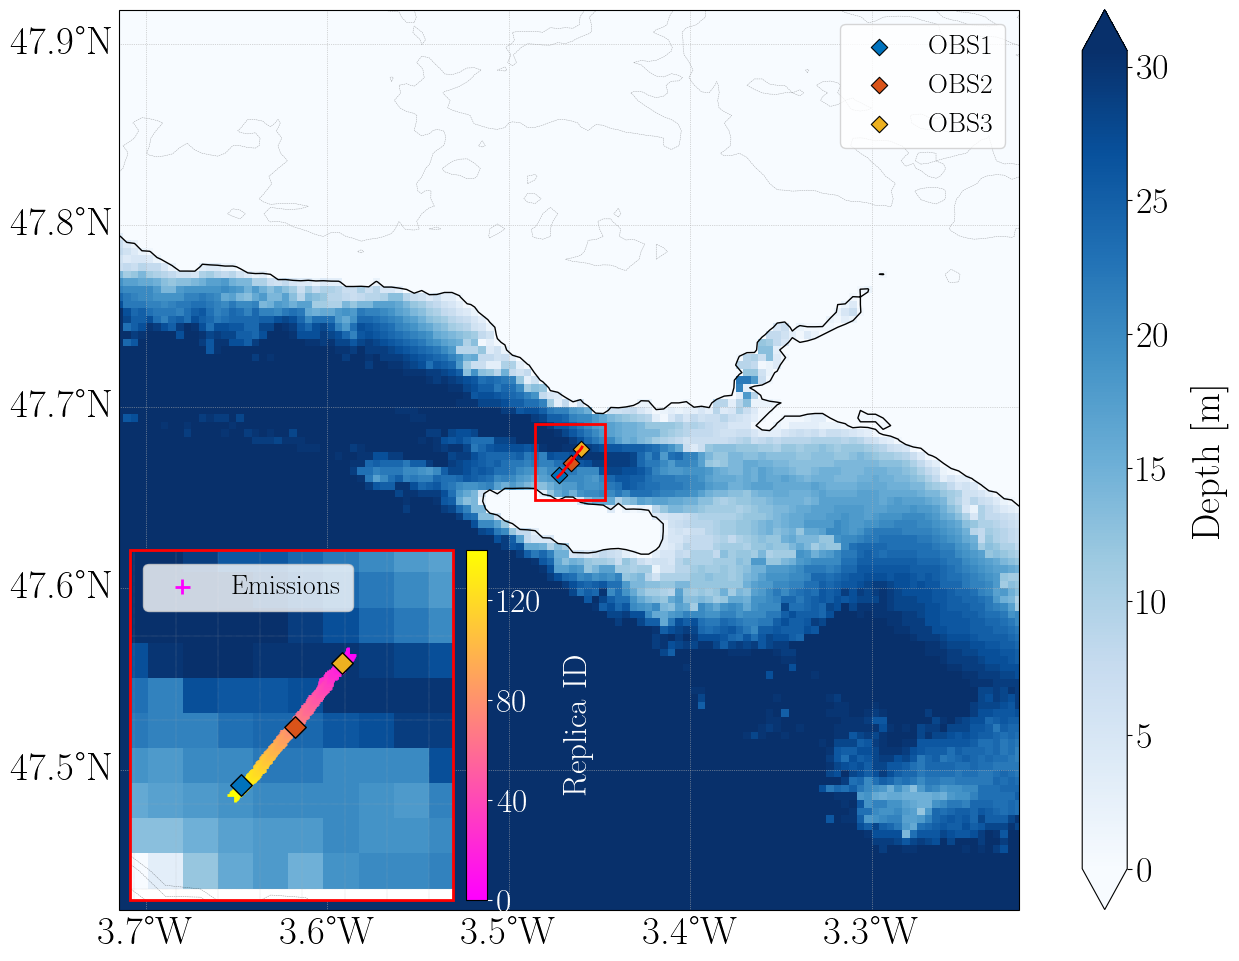

In [10]:
plot_seq_replica_positions_wgs84(df_seq, ds_gps, ds_bathy)

# Restriction aux émissions proches OBS 3

In [11]:
# Select only pulses emitted near OBS3
replica_id_slice_tuple = (10, 50)
replica_id_slice = slice(replica_id_slice_tuple[0], replica_id_slice_tuple[1])
# replica_id_slice = slice(10, 180)
print(replica_id_slice)
pulse_slice_sel = (
    replica_id_slice_tuple[0] + pulse_slice[0],
    replica_id_slice_tuple[1] + pulse_slice[0],
)
print(pulse_slice_sel)


df_seq = df_seq.loc[df_seq["pulse_id"].between(*pulse_slice_sel)]

slice(10, 50, None)
(50, 90)


(<Figure size 1400x1000 with 4 Axes>,
 <GeoAxes: xlabel='Longitude [°]', ylabel='Latitude [°]'>,
 <GeoAxes: xlabel='Longitude [°]', ylabel='Latitude [°]'>)

c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\IPython\core\events.py:96: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


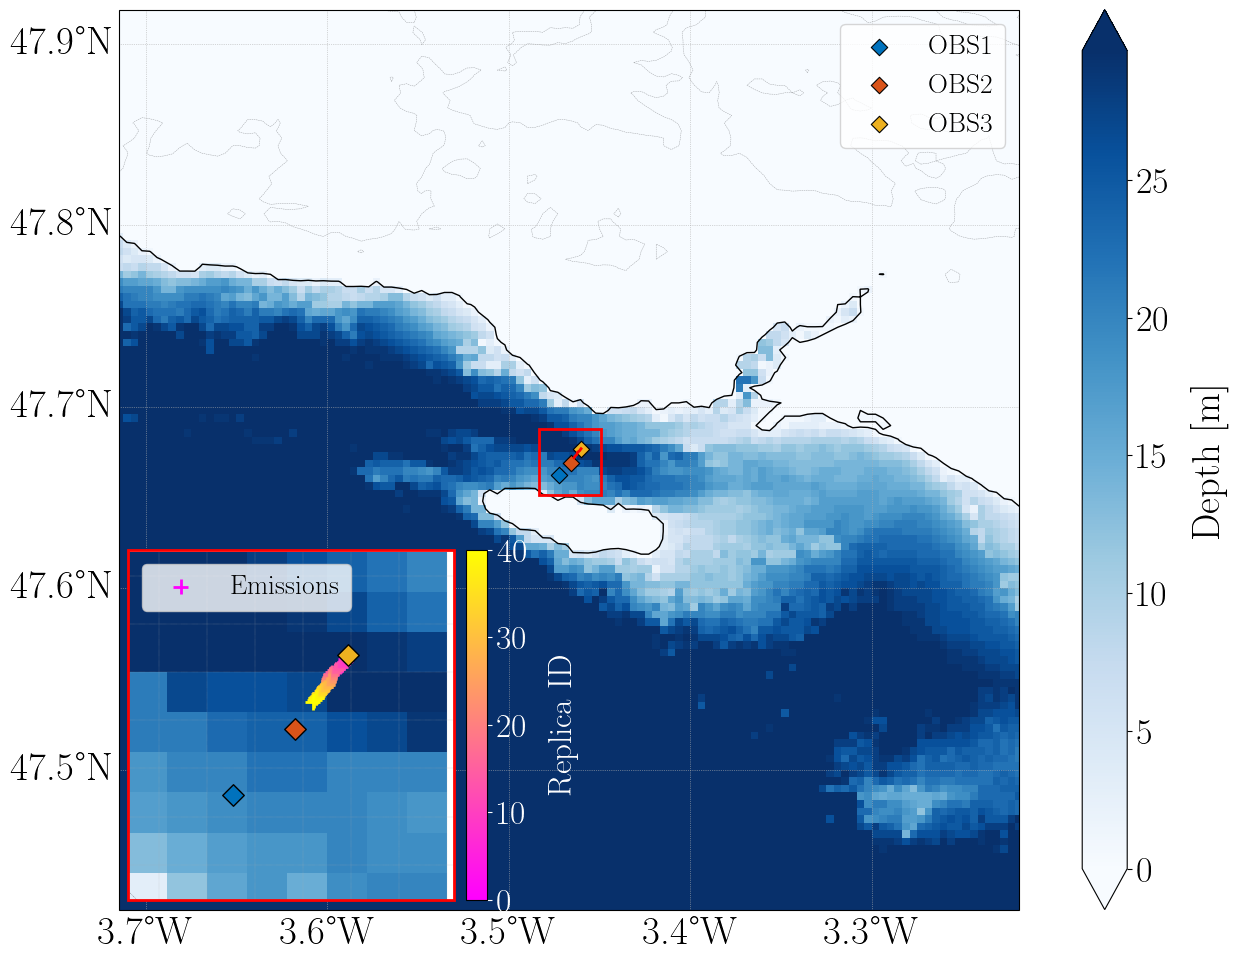

In [12]:
plot_seq_replica_positions_wgs84(df_seq, ds_gps, ds_bathy)

In [13]:
fpath_rbr = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\data\fiberscope_groix_oct_2025\RBR\207416_20251016_1535_data.csv"
df_rbr = pd.read_csv(fpath_rbr, header=0, delimiter=",")
# dt_fmt = df_rbr.columns[0].replace("T", " ")
df_rbr["datetime"] = pd.to_datetime(df_rbr[df_rbr.columns[0]])  # Format is explicit 

In [14]:
# Slice the required sequence
df_rbr_seq = df_rbr.loc[
    df_rbr["datetime"].between(
        df_seq["emission_datetime"].min(), df_seq["emission_datetime"].max()
    )
]

Source depth variations during sequence 144:
	Minimum depth: 9.65 m
	Maximum depth: 9.98 m
	Median depth: 9.84 m


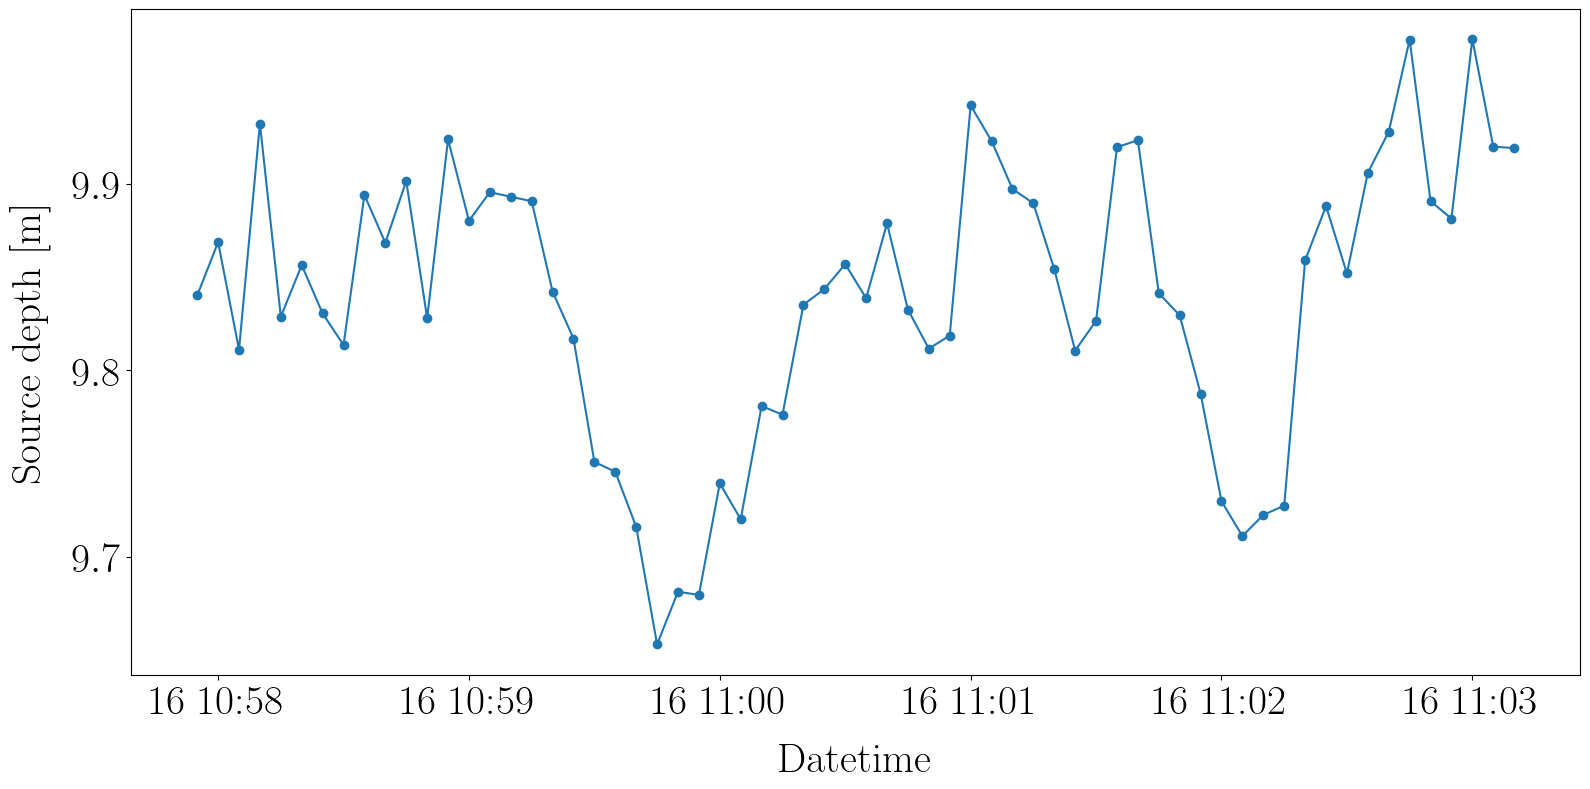

In [15]:
# Plot depth variations along the sequence
plt.figure()
plt.plot(df_rbr_seq["datetime"], df_rbr_seq["Depth [m]"], marker="o")
plt.xlabel("Datetime")
plt.ylabel("Source depth [m]")

print(f"Source depth variations during sequence {seq_id}:")
print(f"\tMinimum depth: {df_rbr_seq['Depth [m]'].min():.2f} m")
print(f"\tMaximum depth: {df_rbr_seq['Depth [m]'].max():.2f} m")
print(f"\tMedian depth: {df_rbr_seq['Depth [m]'].median():.2f} m")

# Capteur 1 : OBS 1 jusqu'a la source la plus éloignée 

In [16]:
# Select profile
profile = f"seq_{seq_id}"

# 22/06/2026
rcv_pos_id = "obs1"
profile = f"{profile}_{rcv_pos_id}"

name = f"xp_fiberscope_groix_{profile}"
title = f"Fiberscope Groix - Profile {profile.upper()}"

# # Dataset path
tf_demo_fpath = os.path.join(data_folder_path, f"tf_demo_{profile}.nc")
tf_prod_fpath = os.path.join(data_folder_path, f"tf_prod_{profile}.nc")
bathy_fpath_csv = os.path.join(data_folder_path, f"bathy_{profile}.csv")

## Définition du profil 

In [17]:
# Définition du profil à modéliser de l'OBS 1 à la position source la plus éloignée

# Start
start_profile_lon = ds_gps.obs1_lon_apriori
start_profile_lat = ds_gps.obs1_lat_apriori
print(f"Profile starts at OBS 1 : (lon = {start_profile_lon}°, lat = {start_profile_lat}°)")

# End
end_profile_lon = df_seq["emission_longitude_gps"].iloc[0]
end_profile_lat = df_seq["emission_latitude_gps"].iloc[0]
print(
    f"Profile ends at source pos : (lon = {end_profile_lon}°, lat = {end_profile_lat}°)"
)

source_depth = 10       # Median depth from above graph 
print(f"Source depth = {source_depth} m ")

Profile starts at OBS 1 : (lon = -3.47226°, lat = 47.66228°)
Profile ends at source pos : (lon = -3.4601570014227834°, lat = 47.67682866709026°)
Source depth = 10 m 


## Extraction de la bathymétrie

In [18]:
extract_bathy = True
dlat_box = 0.1
dlon_box = 0.1

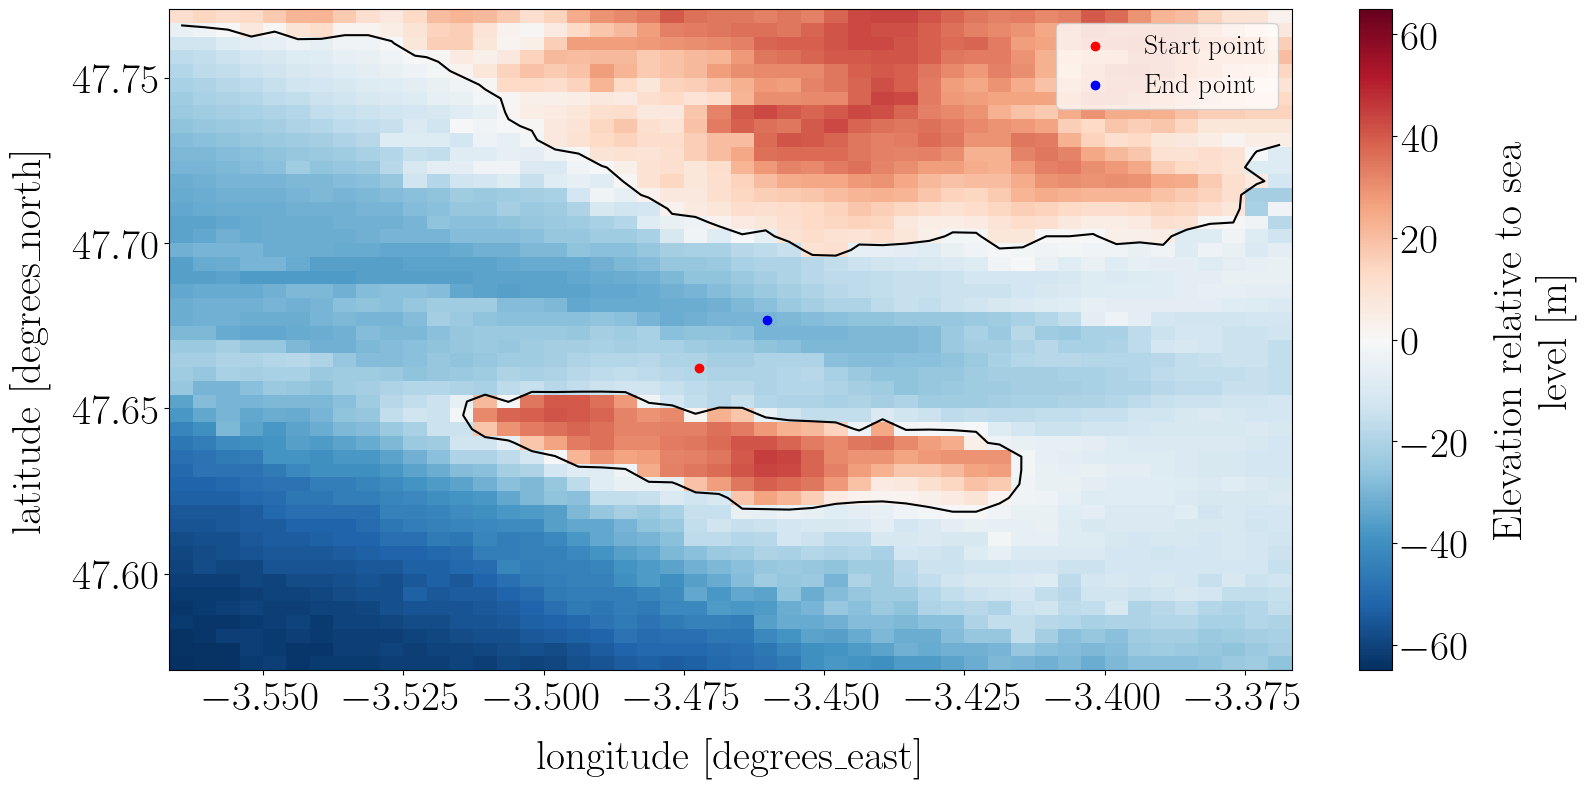

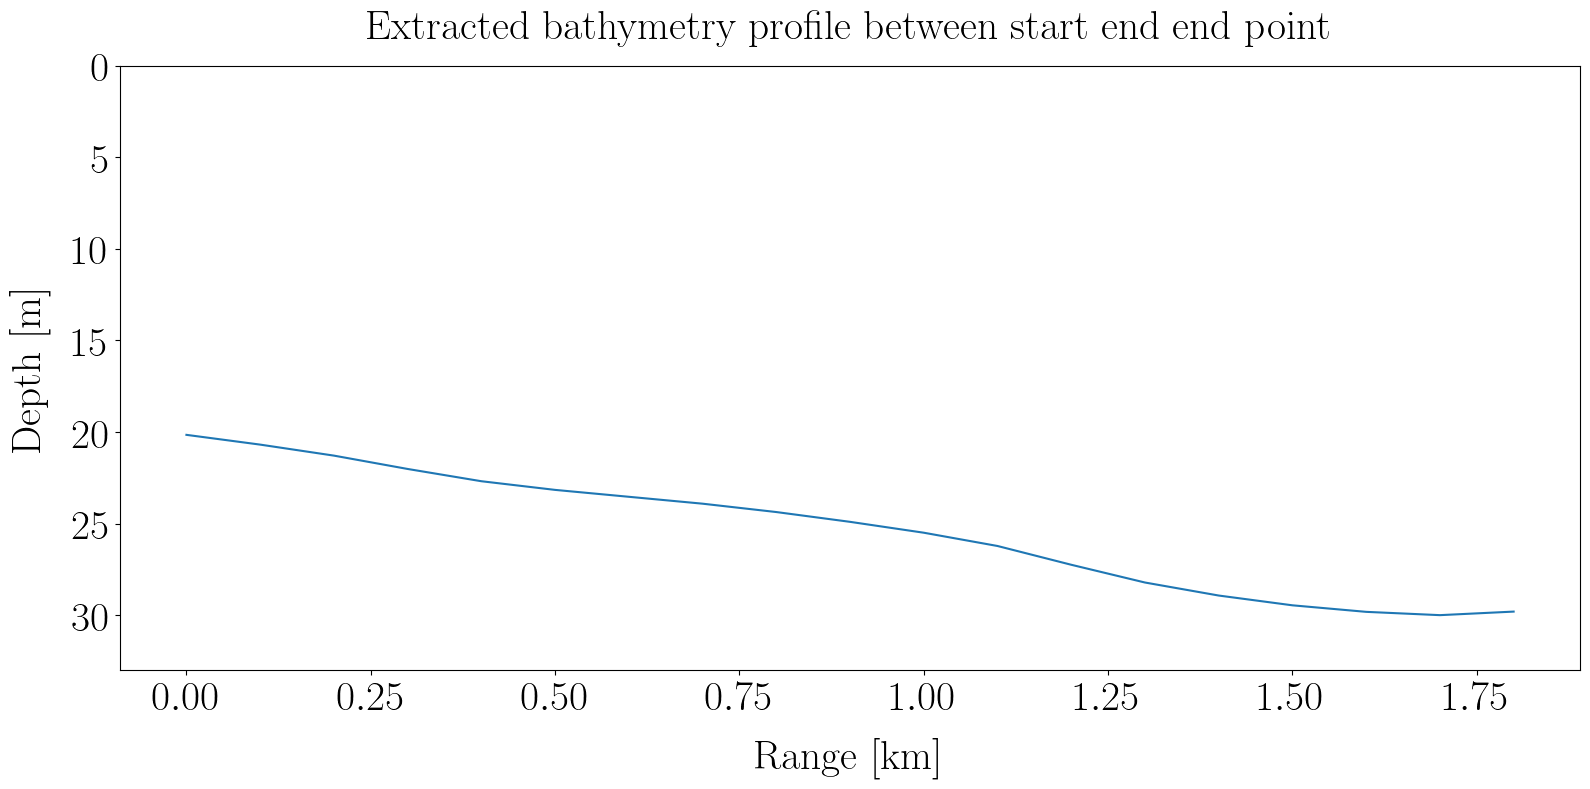

In [19]:
if extract_bathy:
    # Load bathy data
    ds_bathy = xr.open_dataset(bathy_fpath)

    # Slice data to get the area of interest
    ds_bathy = ds_bathy.sel(
        lat=slice(
            ds_gps.obs2_lat_apriori - dlat_box,
            ds_gps.obs2_lat_apriori + dlat_box,
        ),
        lon=slice(
            ds_gps.obs2_lon_apriori  - dlon_box,
            ds_gps.obs2_lon_apriori  + dlon_box,
        ),
    )

    # Plot elevation
    plt.figure()
    ds_bathy.elevation.plot()
    plt.scatter(
        start_profile_lon,
        start_profile_lat,
        color="red",
        label="Start point",
    )
    plt.scatter(
        end_profile_lon,
        end_profile_lat,
        color="blue",
        label="End point",
    )

    # Add contours
    plt.contour(
        ds_bathy.lon, ds_bathy.lat, ds_bathy.elevation, levels=[-0], colors="black"
    )
    plt.legend()

    # Extract bathy along the path between OBS3 and T5
    dr = 100
    # Rename variable to suit function input elevation -> bathymetry
    ds_bathy = ds_bathy.rename({"elevation": "bathymetry"})

    range_along_profile, bathymetry_profile = bpe.extract_bathy_profile(
        xr_bathy=ds_bathy,
        start_lat=start_profile_lat,
        start_lon=start_profile_lon,
        stop_lat=end_profile_lat,
        stop_lon=end_profile_lon,
        range_resolution=dr,
    )
    # Set positive bathymetry down
    bathymetry_profile = -bathymetry_profile

    # Plot extracted profile
    plt.figure()
    plt.plot(range_along_profile / 1e3, bathymetry_profile)
    plt.xlabel("Range [km]")
    plt.ylabel("Depth [m]")
    plt.title("Extracted bathymetry profile between start end end point")
    plt.ylim(0, np.max(bathymetry_profile) * 1.1)
    plt.gca().invert_yaxis()

    # Define bathy object for kraken
    bathy_arr = np.array([range_along_profile * 1e-3, bathymetry_profile]).T
    # Convert to datafram
    df_bathy = pd.DataFrame(bathy_arr)
    # Save to csv
    df_bathy.to_csv(bathy_fpath_csv, index=False, header=False)

In [20]:
# # Dummy testcase to init directories
dummmy_tc = KrakenTestCase(
    name=name,
    root_dir=tc_root_dir,
)

In [21]:
bathy1 = Bathymetry(
    data_file=bathy_fpath_csv,
    interpolation_method="linear",
    units="km",
)

## Paramètres du guide d'onde 

D'après le rapport du SHOM le tracé de rayon est effectué avec un sédiment sable (cf P;14 en dessous de la figure 17). 

In [22]:
# Waveguide geometry
depth = np.ceil(bathy1.bathy_depth.max())  # m
zmin = 0
zmax = depth
max_range_km = bathy1.bathy_range.max()
# max_range_km = 10
rmin = 0
rmax = max_range_km * 1e3

print(f"Waveguide depth: {depth} m")
print(f"Waveguide range: {max_range_km} km")

# Sediment
# bott_props = g.sand_properties
bott_props = g.muddy_sand_sand_properties
# bott_props = g.mixed_sediment_properties
print(f"Sediment properties: {bott_props}")

Waveguide depth: 30.0 m
Waveguide range: 1.8 km
Sediment properties: {'rho': 1.53, 'c_p': 1708, 'c_s': 0.0, 'a_p': 0.91, 'a_s': 0.0}


## Source

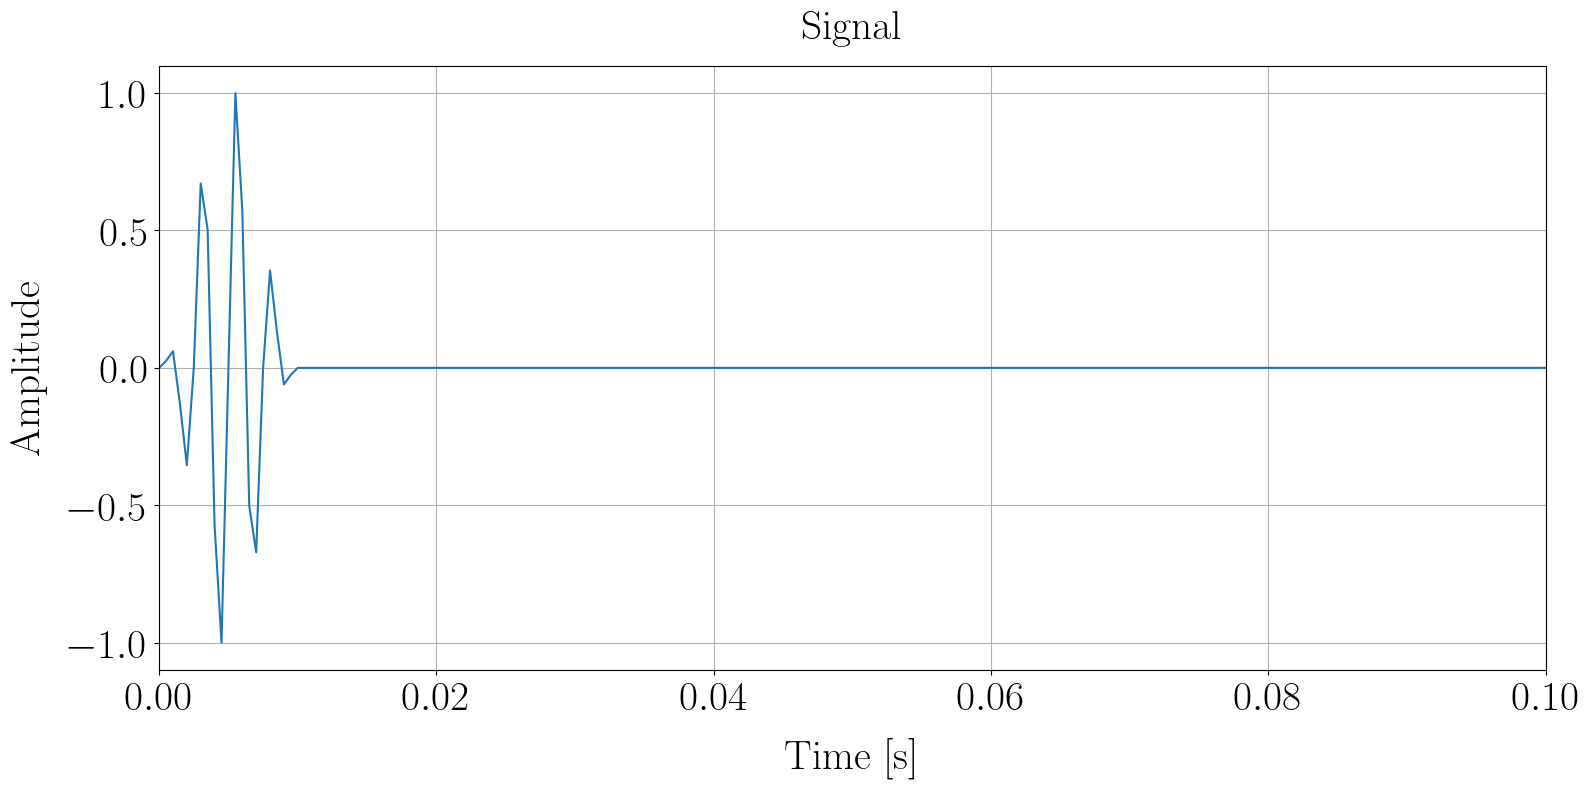

In [23]:
src_depth = bathy1.bathy_depth[0] - 0.5  # m
src_depth1 = src_depth
# src_min_freq = 80 # Hz
# src_max_freq = 1000 # Hz

# Effective bandwidth in which we whant to compare simulation to data
src_min_freq = 400  # Hz
src_max_freq = 800  # Hz

src_fs = 2000  # Hz
src_signal_duration = 4  # s

# Create dummy signal to make it easy to run kraken simulation
fc = src_max_freq / 2  # Hz
sg = SignalGenerator()
s, t = sg.pulse(T=src_signal_duration, fc=fc, fs=src_fs, t0=0)

s = sg.normalize_sig(s, normalize="max")
# Plot time serie
sg.plot_signal(t, s)
plt.gca().set_xlim([0, 0.1])

src = AcousticSource(
    signal=s,
    time=t,
    name="Pulse",
    waveguide_depth=depth,
    window=None,
    nfft=2 ** int(np.log2(s.size) + 1),
)

## Paramètres généraux et objects KrakenEnv

In [24]:
desc =  f"Profile from OBS 1 to pulse emission num {df_seq['pulse_id'].iloc[0]} of sequence {seq_id}"
title = f"Fiberscope Groix - OBS 1 to emission num {df_seq['pulse_id'].iloc[0]} ({seq_id})"
description = f"Transfer functions computed using Kraken for the Fiberscope Groix experiment - {desc}."
note=f"Production dataset with all frequencies in the band of interest {src_min_freq} - {src_max_freq} Hz."
print(title)
print(description)
print(note)

Fiberscope Groix - OBS 1 to emission num 50 (144)
Transfer functions computed using Kraken for the Fiberscope Groix experiment - Profile from OBS 1 to pulse emission num 50 of sequence 144.
Production dataset with all frequencies in the band of interest 400 - 800 Hz.


In [25]:
# Set domain properties
domain_properties = DomainProperties(
    zmin=zmin, zmax=zmax, rmin=rmin, rmax=rmax, unit="m"
)

In [26]:
# Set source properties
src_properties = SourceProperties(
    src_type="point_source", src_depth=src_depth, freq=src.kraken_freq
)

In [27]:
# Set receiver properties : needs to cover the whole water domain
rcv_z_min = zmin
rcv_z_max = zmax * 2
rcv_properties = ReceiverProperties(
    zmin=rcv_z_min, zmax=rcv_z_max, rmin=rmin, rmax=rmax, unit="m"
)

In [28]:
# Set layer properties
nmedia = 2

top_hs = KrakenTopHalfspace(
    boundary_condition="vacuum",
    halfspace_properties=None,
    twersky_scatter_properties=None,
)

bott_hs = KrakenBottomHalfspace(
    boundary_condition="acousto_elastic",
    sigma=0.0,
    halfspace_properties=bott_props,
    fmin=src.kraken_freq.min(),
    alpha_wavelength=2,
)

In [29]:
# Set attenuation properties
att = KrakenAttenuation(units="dB_per_wavelength", use_volume_attenuation=False)

In [30]:
# Set SSP object for kraken

# Constant profile
c0 = 1511  # D'après sondage SBE : très faible variabilité (moins de 1 m.s-1 sur la colonne d'eau)
z_ssp = np.array([0, zmax])
c = np.array([c0, c0])
ssp = SSPProfile(z=z_ssp, c=c)

In [31]:
# Create the medium = water column layer
medium = KrakenMedium(
    ssp_interpolation_method="C_linear",
    z_ssp=ssp.z,
    c_p=ssp.c,
    c_s=0.0,
    rho=g.rho_w * 1e-3,
    a_p=0.0,
    a_s=0.0,
    nmesh=0,
    sigma=0.0,
)

In [32]:
# Set field properties
bott_hs.derive_sedim_layer_max_depth(domain_properties.zmax_m)
max_rcv_depth = bott_hs.sedim_layer_max_depth
n_rcv_z = default_nb_rcv_z(
    fmax=src.kraken_freq.max(), max_depth=max_rcv_depth, n_per_l=10
)

min_phase_speed = 1400
max_phase_speed = 1900

# min_phase_speed = 1400
# max_phase_speed = 1750

field = KrakenField(
    phase_speed_limits=[min_phase_speed, max_phase_speed],
    src_depth=[src_properties.depth],
    n_rcv_z=n_rcv_z,
    rcv_z_min=0,
    rcv_z_max=max_rcv_depth,
    rcv_r_max=0.0,
)

In [33]:
# Set kraken properties
# Number of receiver depths / ranges (flp file)
lambda_min = c0 / src_max_freq
dr = lambda_min / 10
dz = lambda_min / 10
nr_flp = int(rmax / dr) + 1
nz_flp = int(rcv_z_max / dz) + 1

print(f"dr = {dr}m, dz = {dz}m")

kraken_properties = KrakenProperties(
    mode_coupling="coupled",
    mode_addition="coherent",
    n_mode=100,
    nr=nr_flp,
    nz=nz_flp,
    nmedia=nmedia,
    top_hs=top_hs,
    bott_hs=bott_hs,
    att=att,
    medium=medium,
    field=field,
)

dr = 0.188875m, dz = 0.188875m


In [34]:
# Define testcase
k_tc = KrakenTestCase(
    name=name,
    title=title,
    root_dir=tc_root_dir,
    bathy=bathy1,
    domain_properties=domain_properties,
    src_properties=src_properties,
    rcv_properties=rcv_properties,
    kraken_properties=kraken_properties,
)

## Run demo pour vérifier que la simu fonctionne 

In [35]:
# Test with just a few caracteristics frequencies
# run_kraken_demo = True
run_kraken_demo = False

demo_freq = [63, 250, 600]
if run_kraken_demo:
    km = KrakenManager(parallel=True, verbose=True)
    pressure_field, field_pos = km.runkraken(
        env=k_tc.env, flp=k_tc.flp, frequencies=demo_freq
    )

In [36]:
if run_kraken_demo:
    # Store pressure field as netcdf using xarray
    pressure_field_ = np.squeeze(pressure_field)  # Remove singleton dimensions if any
    ds_tf_demo = xr.Dataset(
        data_vars=dict(
            tf_real=(["f", "z", "r"], np.real(pressure_field_)),
            tf_imag=(["f", "z", "r"], np.imag(pressure_field_)),
        ),
        coords=dict(
            f=demo_freq,
            z=field_pos["r"]["z"],
            r=field_pos["r"]["r"],
        ),
        attrs=dict(
            title=f"{title} - Demo",
            description=description,
            # date_created=np.datetime64("now"),
            note="Demo dataset with limited frequencies.",
            type="demo",
            fs=src_fs,
            signal_duration=src_signal_duration,
        ),
    )
    # Save to netcdf
    ds_tf_demo.to_netcdf(tf_demo_fpath)
else:
    # Load transfer functions from netcdf
    ds_tf_demo = xr.open_dataset(tf_demo_fpath)

ds_tf_demo_1 = ds_tf_demo

In [37]:
ds_tf_demo

<xarray.Dataset> Size: 146MB
Dimensions:  (f: 3, z: 318, r: 9531)
Coordinates:
  * f        (f) int32 12B 63 250 600
  * z        (z) float32 1kB 0.0 0.1893 0.3785 0.5678 ... 59.43 59.62 59.81 60.0
  * r        (r) float64 76kB 0.0 0.2099 0.4197 0.6296 ... 2e+03 2e+03 2e+03
Data variables:
    tf_real  (f, z, r) float64 73MB ...
    tf_imag  (f, z, r) float64 73MB ...
Attributes:
    title:            Fiberscope Groix - OBS 1 to emission num 50 (144) - Demo
    description:      Transfer functions computed using Kraken for the Fibers...
    note:             Demo dataset with limited frequencies.
    type:             demo
    fs:               2000
    signal_duration:  4

### Plot de quelques résultats 

In [38]:
# fréquence de coupure du mode m
m = 20
f_0m = ((m - 0.5) * c0) / (2 * depth * np.sqrt(1 - (c0 / bott_props["c_p"]) ** 2))
print(f"Cut-off frequency of mode {m} : {f_0m:.2f} Hz")

Cut-off frequency of mode 20 : 1053.28 Hz


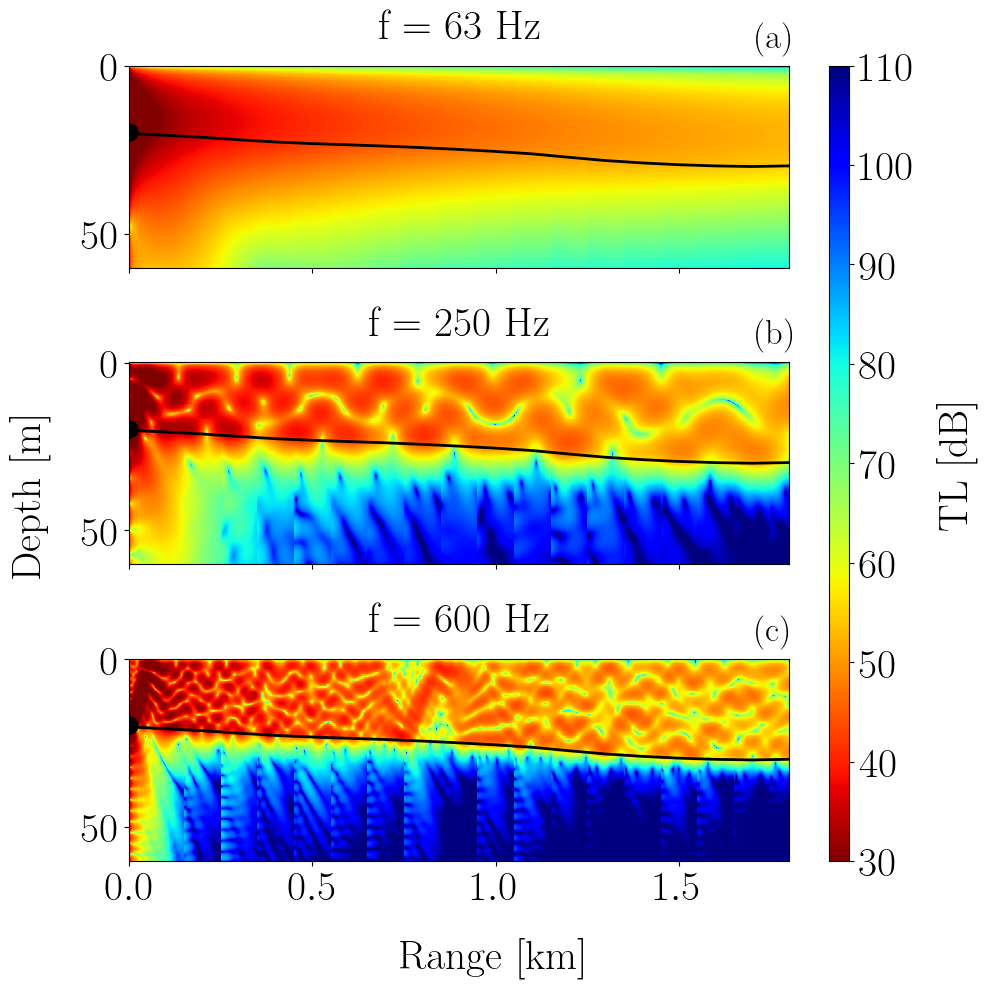

In [39]:
lfig = LargeFigure(size=(16, 7.5))

# Plot tl at a single frequency
tf_demo = ds_tf_demo.tf_real + 1j * ds_tf_demo.tf_imag  # (nf, nz, nr)
freq_plot = demo_freq
p_field = tf_demo.sel(f=freq_plot, method="nearest").values
p_field[(p_field == 0) | np.isnan(p_field)] = 1e-20 
tl = - 20 * np.log10(np.abs(p_field)) 
# tlmax = np.percentile(tl, 95)
# tlmin = np.percentile(tl, 1)

tlmax = 110
tlmin = 30

# Plot TL for each number of modes
fig, axs = plt.subplots(len(freq_plot), figsize=(10, 10), sharex=True)
abcd_labels = ["a", "b", "c"]
for i, fp in enumerate(freq_plot):
    p_field = p_field[i, ...]
    title = f"f = {fp} Hz"

    # Plot TL
    im = axs[i].pcolormesh(
        tf_demo.r * 1e-3,
        tf_demo.z,
        tl[i],
        cmap="jet_r",
        vmin=tlmin,
        vmax=tlmax,
        rasterized=True,
    )

    # Add source position
    if src_depth is not None:
        axs[i].scatter(
            0,
            src_depth,
            color="k",
            marker="o",
            s=150,
        )
    axs[i].set_title(title)
    axs[i].invert_yaxis()

    # Add a, b, c labels
    axs[i].text(
        0.95,
        1.05,
        f"({abcd_labels[i]})",
        transform=axs[i].transAxes,
        fontsize=25,
        fontweight="bold",
        va="bottom",
    )

    # Add bathy
    axs[i].plot(bathy1.bathy_range, bathy1.bathy_depth, color="k", linewidth=2)
    # Limit to bathy range
    axs[i].set_xlim([0, bathy1.bathy_range.max()])

fig.supxlabel("Range [km]")
fig.supylabel("Depth [m]")

# Add common colorbar
cbar = fig.colorbar(im, ax=axs, orientation="vertical", pad=0.05, aspect=40)
cbar.set_label("TL [dB]")


# # Save figure as pdf
# fpath = os.path.join(img_folder_path, f"{name}_tl_3freqs.pdf")
# plt.savefig(fpath)

## Calcul des fonctions de Green du guide d'onde étudié

In [40]:
# Reset kraken properties with much lower output field resolution for memory issues
# Number of receiver depths / ranges (flp file)
lambda_min = g.c0 / src_max_freq
dr = 0.5
dz = 1
nr_flp = int(rmax / dr) + 1
nz_flp = int(rcv_z_max / dz) + 1

kraken_properties = KrakenProperties(
    mode_coupling="coupled",
    mode_addition="coherent",
    n_mode=50,
    nr=nr_flp,
    nz=nz_flp,
    nmedia=nmedia,
    top_hs=top_hs,
    bott_hs=bott_hs,
    att=att,
    medium=medium,
    field=field,
)

# re-Define testcase to update flp props
k_tc = KrakenTestCase(
    name=name,
    title=title,
    root_dir=tc_root_dir,
    bathy=bathy1,
    domain_properties=domain_properties,
    src_properties=src_properties,
    rcv_properties=rcv_properties,
    kraken_properties=kraken_properties,
)

In [41]:
# Kraken compute otpion
run_kraken = False
# run_kraken = True

In [42]:
run_freq = k_tc.src.freq[
    (k_tc.src.freq >= src_min_freq) & (k_tc.src.freq <= src_max_freq)
]
f_before = src.positive_freq[src.positive_freq < run_freq.min()]
pad_before = f_before.size
f_after = src.positive_freq[src.positive_freq > run_freq.max()]
pad_after = f_after.size

In [43]:
# Evaluate expected cpu time
if run_kraken:
    nproc = N_CORES

    run_freq_cpu_test = run_freq[-nproc :]      # Test with highest frequencies -> worst case scenario
    nf_cpu_test = run_freq_cpu_test.size

    # Run a quick test to estimate cpu time
    t0 = time()
    km = KrakenManager(parallel=False, verbose=True)
    _, _ = km.runkraken(
        env=k_tc.env, flp=k_tc.flp, frequencies=run_freq_cpu_test
    )
    cpu_time = time() - t0

    avg_cpu_time_per_freq = cpu_time / nf_cpu_test
    estimated_cpu_time = avg_cpu_time_per_freq * run_freq.size / nproc

    print(
        f"Max expected cpu time: {estimated_cpu_time / 60:.2f} min for {run_freq.size} frequencies on {nproc} cores"
    )


In [44]:
if run_kraken:
    km = KrakenManager(parallel=True, verbose=True)
    pressure_field, field_pos = km.runkraken(
        env=k_tc.env, flp=k_tc.flp, frequencies=run_freq
    )

    pressure_field_real = np.real(pressure_field).astype(np.float32)
    pressure_field_img = np.imag(pressure_field).astype(np.float32)
    # Pad with zeros to get the full frequency band
    pad_tuple = ((pad_before, pad_after),) + ((0, 0),)*(len(pressure_field.shape)-1)
    pressure_field_real = np.pad(
        pressure_field_real, pad_tuple, mode="constant", constant_values=0
    )
    pressure_field_img = np.pad(
        pressure_field_img, pad_tuple, mode="constant", constant_values=0
    )
    # pressure_field = np.pad(pressure_field, pad_tuple, mode="constant", constant_values=0)

## Sauvergarde des fonctions de transfert du guide d'onde 

In [45]:
if run_kraken:
    # Store pressure field as netcdf using xarray
    # pressure_field = np.squeeze(pressure_field)  # Remove singleton dimensions if any
    pressure_field_real = np.squeeze(pressure_field_real)
    pressure_field_img = np.squeeze(pressure_field_img)

    ds_tf = xr.Dataset(
        data_vars=dict(
            tf_real=(["f", "z", "r"], pressure_field_real),
            tf_imag=(["f", "z", "r"], pressure_field_img),
        ),
        coords=dict(
            f=src.positive_freq.astype(np.float32),
            z=field_pos["r"]["z"].astype(np.float32),
            r=field_pos["r"]["r"].astype(np.float32),
        ),
        attrs=dict(
            title=title,
            description=description,
            # date_created=np.datetime64("now"),
            note=note,
            type="prod",
            fs=src_fs,
            signal_duration=src_signal_duration,
        ),
    )

    # Limit z extension
    zmax = np.ceil(bathy1.bathy_depth.max()+dz)
    ds_tf = ds_tf.sel(z=slice(0, zmax))
    # Save to netcdf
    ds_tf.to_netcdf(tf_prod_fpath)
else:
    # Load transfer functions from netcdf
    ds_tf = xr.open_dataset(tf_prod_fpath)

ds_tf_obs1 = ds_tf

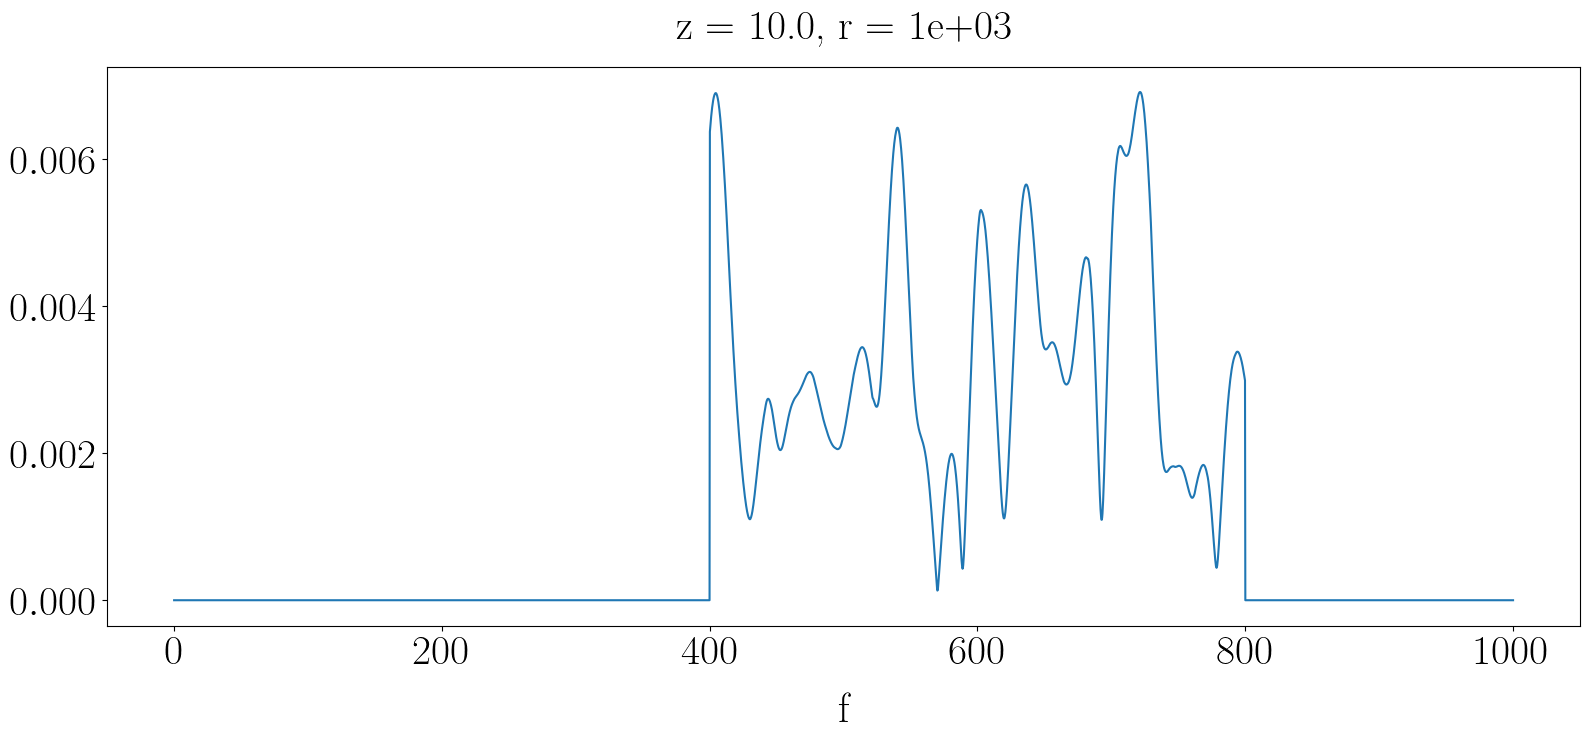

In [46]:
ds_tf_sel = ds_tf_obs1.sel(z=source_depth, r=1000, method="nearest")
tf_sel = ds_tf_sel.tf_real + 1j * ds_tf_sel.tf_imag

np.abs(tf_sel).plot(x="f")
# plt.xlim([src_min_freq, src_max_freq])

c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\xarray\computation\apply_ufunc.py:820: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\numpy\lib\function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


(400.0, 800.0)

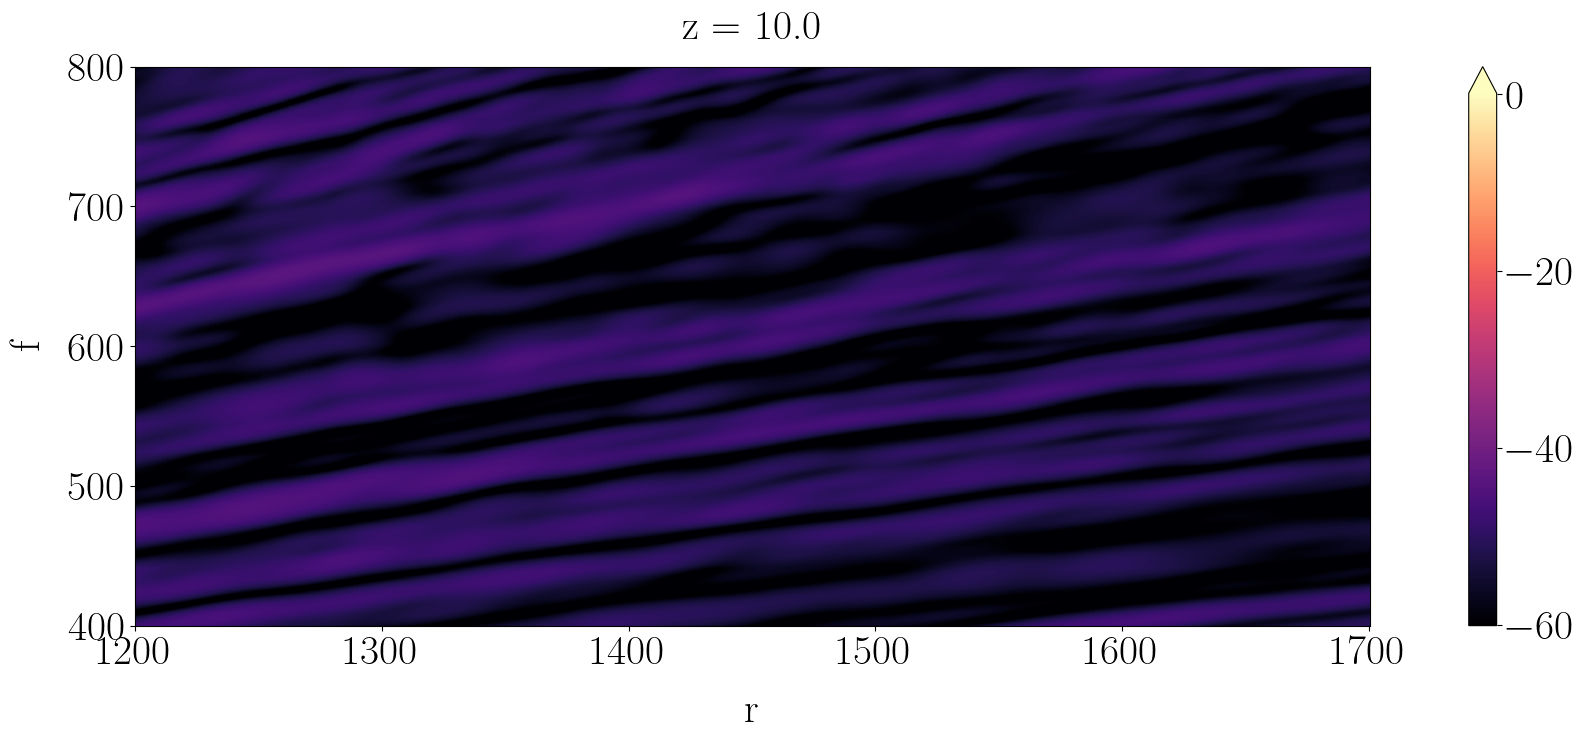

In [47]:
ds_tf_sel = ds_tf_obs1.sel(z=source_depth, method="nearest").sel(
    r=slice(1200, 1700),
)
tf_sel = ds_tf_sel.tf_real + 1j * ds_tf_sel.tf_imag

tl = 20 * np.log10(np.abs(tf_sel))
tl.plot(x="r", cmap="magma", vmin=np.percentile(tl, 50), vmax=np.percentile(tl, 75))
plt.ylim([src_min_freq, src_max_freq])

# Capteur 2 : OBS 2 jusqu'a la source la plus éloignée 

In [48]:
profile = f"seq_{seq_id}"

# 22/06/2026
rcv_pos_id = "obs2"
profile = f"{profile}_{rcv_pos_id}"
# src_pos_id = "end_seq_144"

name = f"xp_fiberscope_groix_{profile}"
title = f"Fiberscope Groix - Profile {profile.upper()}"

# # Dataset path
tf_demo_fpath = os.path.join(data_folder_path, f"tf_demo_{profile}.nc")
tf_prod_fpath = os.path.join(data_folder_path, f"tf_prod_{profile}.nc")
bathy_fpath_csv = os.path.join(data_folder_path, f"bathy_{profile}.csv")

In [49]:
print(tf_demo_fpath)
print(tf_prod_fpath)

C:\Users\baptiste.menetrier\Desktop\devPy\phd\propa\rtf\rtf_estimation\xp_fiberscope_groix\data\tf_demo_seq_144_obs2.nc
C:\Users\baptiste.menetrier\Desktop\devPy\phd\propa\rtf\rtf_estimation\xp_fiberscope_groix\data\tf_prod_seq_144_obs2.nc


## Définition du profil 

In [50]:
# Définition du profil à modéliser de l'OBS 1 à la position source la plus éloignée

# Start
start_profile_lon = ds_gps.obs2_lon_apriori
start_profile_lat = ds_gps.obs2_lat_apriori
print(f"Profile starts at OBS 2 : (lon = {start_profile_lon}°, lat = {start_profile_lat}°)")

# End
end_profile_lon = df_seq["emission_longitude_gps"].iloc[0]
end_profile_lat = df_seq["emission_latitude_gps"].iloc[0]
print(
    f"Profile ends at source pos : (lon = {end_profile_lon}°, lat = {end_profile_lat}°)"
)

source_depth = 10       # Median depth from depth graph 
print(f"Source depth = {source_depth} m ")

Profile starts at OBS 2 : (lon = -3.46584°, lat = 47.66911°)
Profile ends at source pos : (lon = -3.4601570014227834°, lat = 47.67682866709026°)
Source depth = 10 m 


## Extraction de la bathymétrie

In [51]:
extract_bathy = True
dlat_box = 0.1
dlon_box = 0.1

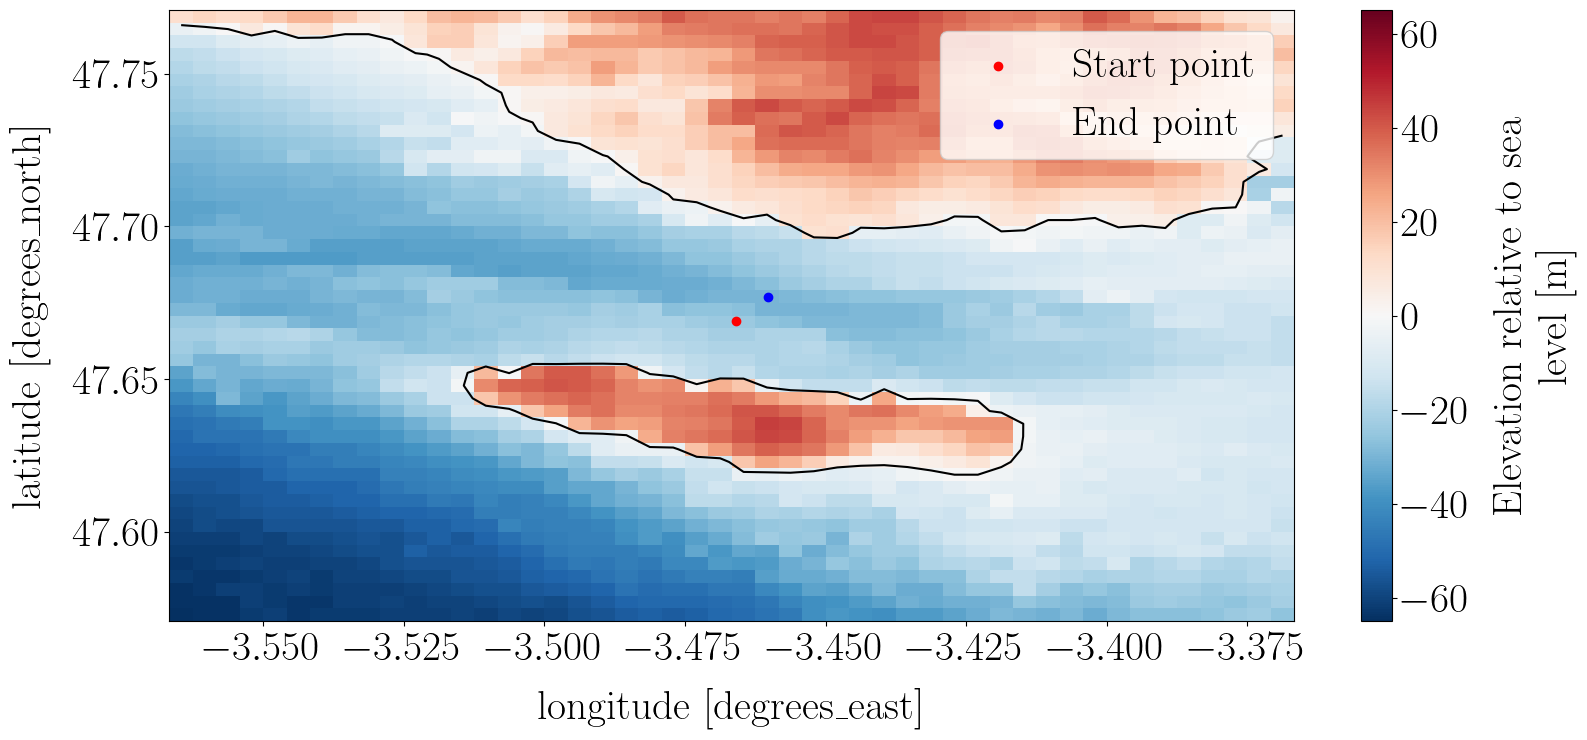

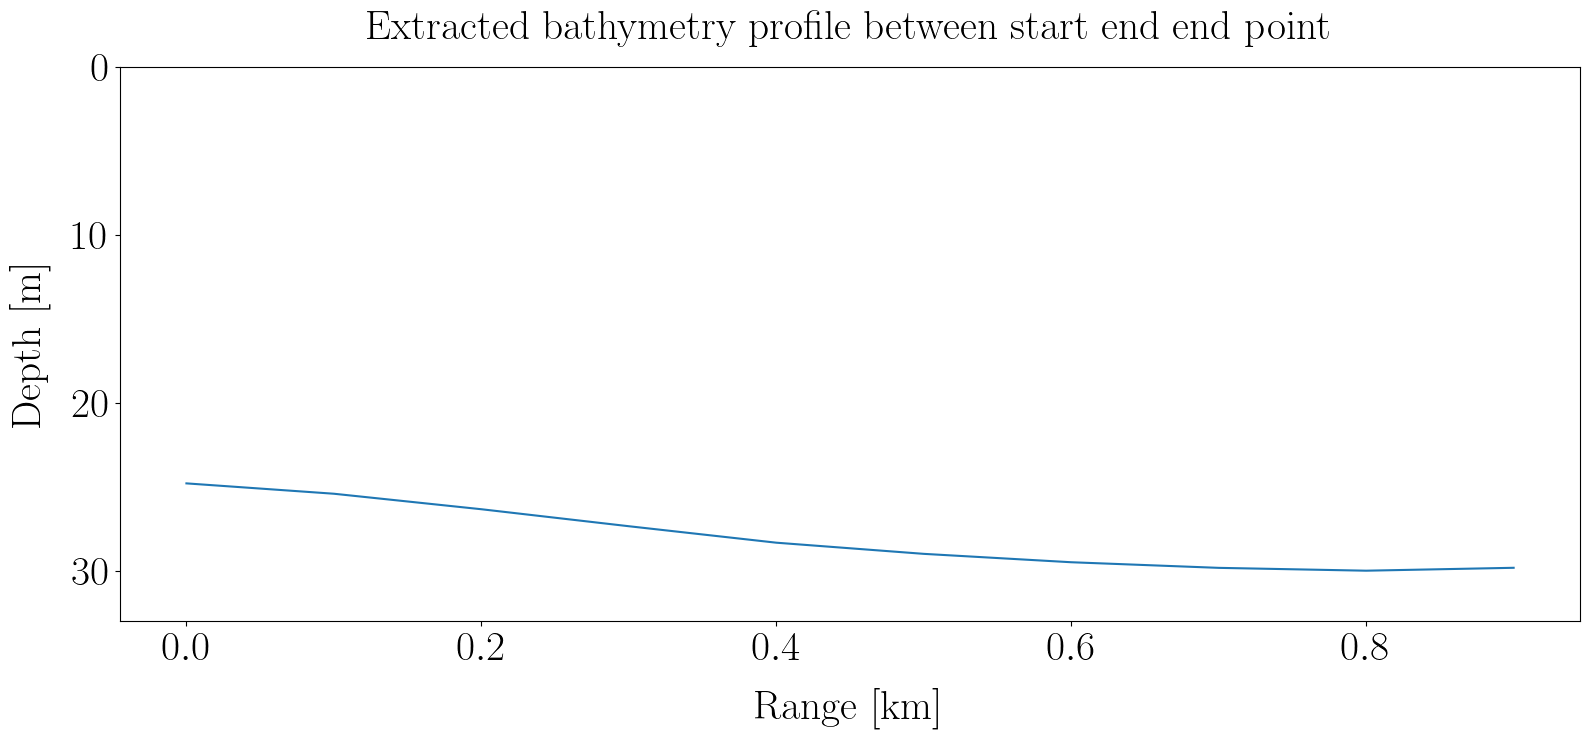

In [52]:
if extract_bathy:
    # Load bathy data
    ds_bathy = xr.open_dataset(bathy_fpath)

    # Slice data to get the area of interest
    ds_bathy = ds_bathy.sel(
        lat=slice(
            ds_gps.obs2_lat_apriori - dlat_box,
            ds_gps.obs2_lat_apriori + dlat_box,
        ),
        lon=slice(
            ds_gps.obs2_lon_apriori  - dlon_box,
            ds_gps.obs2_lon_apriori  + dlon_box,
        ),
    )

    # Plot elevation
    plt.figure()
    ds_bathy.elevation.plot()
    plt.scatter(
        start_profile_lon,
        start_profile_lat,
        color="red",
        label="Start point",
    )
    plt.scatter(
        end_profile_lon,
        end_profile_lat,
        color="blue",
        label="End point",
    )

    # Add contours
    plt.contour(
        ds_bathy.lon, ds_bathy.lat, ds_bathy.elevation, levels=[-0], colors="black"
    )
    plt.legend()

    # Extract bathy along the path between OBS3 and T5
    dr = 100
    # Rename variable to suit function input elevation -> bathymetry
    ds_bathy = ds_bathy.rename({"elevation": "bathymetry"})

    range_along_profile, bathymetry_profile = bpe.extract_bathy_profile(
        xr_bathy=ds_bathy,
        start_lat=start_profile_lat,
        start_lon=start_profile_lon,
        stop_lat=end_profile_lat,
        stop_lon=end_profile_lon,
        range_resolution=dr,
    )
    # Set positive bathymetry down
    bathymetry_profile = -bathymetry_profile

    # Plot extracted profile
    plt.figure()
    plt.plot(range_along_profile / 1e3, bathymetry_profile)
    plt.xlabel("Range [km]")
    plt.ylabel("Depth [m]")
    plt.title("Extracted bathymetry profile between start end end point")
    plt.ylim(0, np.max(bathymetry_profile) * 1.1)
    plt.gca().invert_yaxis()

    # Define bathy object for kraken
    bathy_arr = np.array([range_along_profile * 1e-3, bathymetry_profile]).T
    # Convert to datafram
    df_bathy = pd.DataFrame(bathy_arr)
    # Save to csv
    df_bathy.to_csv(bathy_fpath_csv, index=False, header=False)

In [53]:
bathy2 = Bathymetry(
    data_file=bathy_fpath_csv,
    interpolation_method="linear",
    units="km",
)

## Paramètres du guide d'onde 

D'après le rapport du SHOM le tracé de rayon est effectué avec un sédiment sable (cf P;14 en dessous de la figure 17). 

In [54]:
# Waveguide geometry
depth = np.ceil(bathy2.bathy_depth.max())  # m
zmin = 0
zmax = depth
max_range_km = bathy2.bathy_range.max()
# max_range_km = 10
rmin = 0
rmax = max_range_km * 1e3

print(f"Waveguide depth: {depth} m")
print(f"Waveguide range: {max_range_km} km")

# Sediment
# bott_props = g.sand_properties
bott_props = g.muddy_sand_sand_properties
# bott_props = g.mixed_sediment_properties
print(f"Sediment properties: {bott_props}")

Waveguide depth: 30.0 m
Waveguide range: 0.9 km
Sediment properties: {'rho': 1.53, 'c_p': 1708, 'c_s': 0.0, 'a_p': 0.91, 'a_s': 0.0}


## Source

In [55]:
src_depth = bathy2.bathy_depth[0] - 0.5  # m
src_depth2 = src_depth
# src_min_freq = 80 # Hz
# src_max_freq = 1000 # Hz

# Effective bandwidth in which we whant to compare simulation to data
src_min_freq = 400  # Hz
src_max_freq = 800  # Hz

src_fs = 2000  # Hz
src_signal_duration = 4  # s

# Create dummy signal to make it easy to run kraken simulation
fc = src_max_freq / 2  # Hz
sg = SignalGenerator()
s, t = sg.pulse(T=src_signal_duration, fc=fc, fs=src_fs, t0=0)

s = sg.normalize_sig(s, normalize="max")
# # Plot time serie
# sg.plot_signal(t, s)
# plt.gca().set_xlim([0, 0.1])

src = AcousticSource(
    signal=s,
    time=t,
    name="Pulse",
    waveguide_depth=depth,
    window=None,
    nfft=2 ** int(np.log2(s.size) + 1),
)

## Paramètres généraux et objects KrakenEnv

In [56]:
desc =  f"Profile from OBS 2 to pulse emission num {df_seq['pulse_id'].iloc[0]} of sequence {seq_id}"
title = f"Fiberscope Groix - OBS 2 to emission num {df_seq['pulse_id'].iloc[0]} ({seq_id})"
description = f"Transfer functions computed using Kraken for the Fiberscope Groix experiment - {desc}."
note=f"Production dataset with all frequencies in the band of interest {src_min_freq} - {src_max_freq} Hz."
print(title)
print(description)
print(note)

Fiberscope Groix - OBS 2 to emission num 50 (144)
Transfer functions computed using Kraken for the Fiberscope Groix experiment - Profile from OBS 2 to pulse emission num 50 of sequence 144.
Production dataset with all frequencies in the band of interest 400 - 800 Hz.


In [57]:
# Set domain properties
domain_properties = DomainProperties(
    zmin=zmin, zmax=zmax, rmin=rmin, rmax=rmax, unit="m"
)

In [58]:
# Set source properties
src_properties = SourceProperties(
    src_type="point_source", src_depth=src_depth, freq=src.kraken_freq
)

In [59]:
# Set receiver properties : needs to cover the whole water domain
rcv_z_min = zmin
rcv_z_max = zmax * 2
rcv_properties = ReceiverProperties(
    zmin=rcv_z_min, zmax=rcv_z_max, rmin=rmin, rmax=rmax, unit="m"
)

In [60]:
# Set layer properties
nmedia = 2

top_hs = KrakenTopHalfspace(
    boundary_condition="vacuum",
    halfspace_properties=None,
    twersky_scatter_properties=None,
)

bott_hs = KrakenBottomHalfspace(
    boundary_condition="acousto_elastic",
    sigma=0.0,
    halfspace_properties=bott_props,
    fmin=src.kraken_freq.min(),
    alpha_wavelength=2,
)

In [61]:
# Set attenuation properties
att = KrakenAttenuation(units="dB_per_wavelength", use_volume_attenuation=False)

In [62]:
# Set SSP object for kraken

# Constant profile
c0 = 1511  # D'après sondage SBE : très faible variabilité (moins de 1 m.s-1 sur la colonne d'eau)
z_ssp = np.array([0, zmax])
c = np.array([c0, c0])
ssp = SSPProfile(z=z_ssp, c=c)

In [63]:
# Create the medium = water column layer
medium = KrakenMedium(
    ssp_interpolation_method="C_linear",
    z_ssp=ssp.z,
    c_p=ssp.c,
    c_s=0.0,
    rho=g.rho_w * 1e-3,
    a_p=0.0,
    a_s=0.0,
    nmesh=0,
    sigma=0.0,
)

In [64]:
# Set field properties
bott_hs.derive_sedim_layer_max_depth(domain_properties.zmax_m)
max_rcv_depth = bott_hs.sedim_layer_max_depth
n_rcv_z = default_nb_rcv_z(
    fmax=src.kraken_freq.max(), max_depth=max_rcv_depth, n_per_l=10
)
# print(max_rcv_depth)

# min_phase_speed = 1400
# max_phase_speed = 1800

min_phase_speed = 1400
max_phase_speed = 1750

field = KrakenField(
    phase_speed_limits=[min_phase_speed, max_phase_speed],
    src_depth=[src_properties.depth],
    n_rcv_z=n_rcv_z,
    rcv_z_min=0,
    rcv_z_max=max_rcv_depth,
    rcv_r_max=0.0,
)

In [65]:
# Set kraken properties
# Number of receiver depths / ranges (flp file)
lambda_min = c0 / src_max_freq
dr = lambda_min / 10
dz = lambda_min / 10
nr_flp = int(rmax / dr) + 1
nz_flp = int(rcv_z_max / dz) + 1

print(f"dr = {dr}m, dz = {dz}m")

kraken_properties = KrakenProperties(
    mode_coupling="coupled",
    mode_addition="coherent",
    n_mode=100,
    nr=nr_flp,
    nz=nz_flp,
    nmedia=nmedia,
    top_hs=top_hs,
    bott_hs=bott_hs,
    att=att,
    medium=medium,
    field=field,
)

dr = 0.188875m, dz = 0.188875m


In [66]:
# Define testcase
k_tc = KrakenTestCase(
    name=name,
    title=title,
    root_dir=tc_root_dir,
    bathy=bathy2,
    domain_properties=domain_properties,
    src_properties=src_properties,
    rcv_properties=rcv_properties,
    kraken_properties=kraken_properties,
)

## Run demo pour vérifier que la simu fonctionne 

In [67]:
# Test with just a few caracteristics frequencies
# run_kraken_demo = True
run_kraken_demo = False

demo_freq = [63, 250, 600]
if run_kraken_demo:
    km = KrakenManager(parallel=True, verbose=True)
    pressure_field, field_pos = km.runkraken(
        env=k_tc.env, flp=k_tc.flp, frequencies=demo_freq
    )

In [68]:
if run_kraken_demo:
    # Store pressure field as netcdf using xarray
    pressure_field_ = np.squeeze(pressure_field)  # Remove singleton dimensions if any
    ds_tf_demo = xr.Dataset(
        data_vars=dict(
            tf_real=(["f", "z", "r"], np.real(pressure_field_)),
            tf_imag=(["f", "z", "r"], np.imag(pressure_field_)),
        ),
        coords=dict(
            f=demo_freq,
            z=field_pos["r"]["z"],
            r=field_pos["r"]["r"],
        ),
        attrs=dict(
            title=f"{title} - Demo",
            description=description,
            # date_created=np.datetime64("now"),
            note="Demo dataset with limited frequencies.",
            type="demo",
            fs=src_fs,
            signal_duration=src_signal_duration,
        ),
    )
    # Save to netcdf
    ds_tf_demo.to_netcdf(tf_demo_fpath)
else:
    # Load transfer functions from netcdf
    ds_tf_demo = xr.open_dataset(tf_demo_fpath)

ds_tf_demo_2 = ds_tf_demo

In [69]:
ds_tf_demo

<xarray.Dataset> Size: 73MB
Dimensions:  (f: 3, z: 318, r: 4766)
Coordinates:
  * f        (f) int32 12B 63 250 600
  * z        (z) float32 1kB 0.0 0.1893 0.3785 0.5678 ... 59.43 59.62 59.81 60.0
  * r        (r) float64 38kB 0.0 0.2099 0.4197 0.6296 ... 999.6 999.8 1e+03
Data variables:
    tf_real  (f, z, r) float64 36MB ...
    tf_imag  (f, z, r) float64 36MB ...
Attributes:
    title:            Fiberscope Groix - OBS 2 to emission num 50 (144) - Demo
    description:      Transfer functions computed using Kraken for the Fibers...
    note:             Demo dataset with limited frequencies.
    type:             demo
    fs:               2000
    signal_duration:  4

### Plot de quelques résultats 

In [70]:
# fréquence de coupure du mode m
m = 17
f_0m = ((m - 0.5) * g.c0) / (2 * depth * np.sqrt(1 - (g.c0 / bott_props["c_p"]) ** 2))
print(f"Cut-off frequency of mode {m} : {f_0m:.2f} Hz")

Cut-off frequency of mode 17 : 862.51 Hz


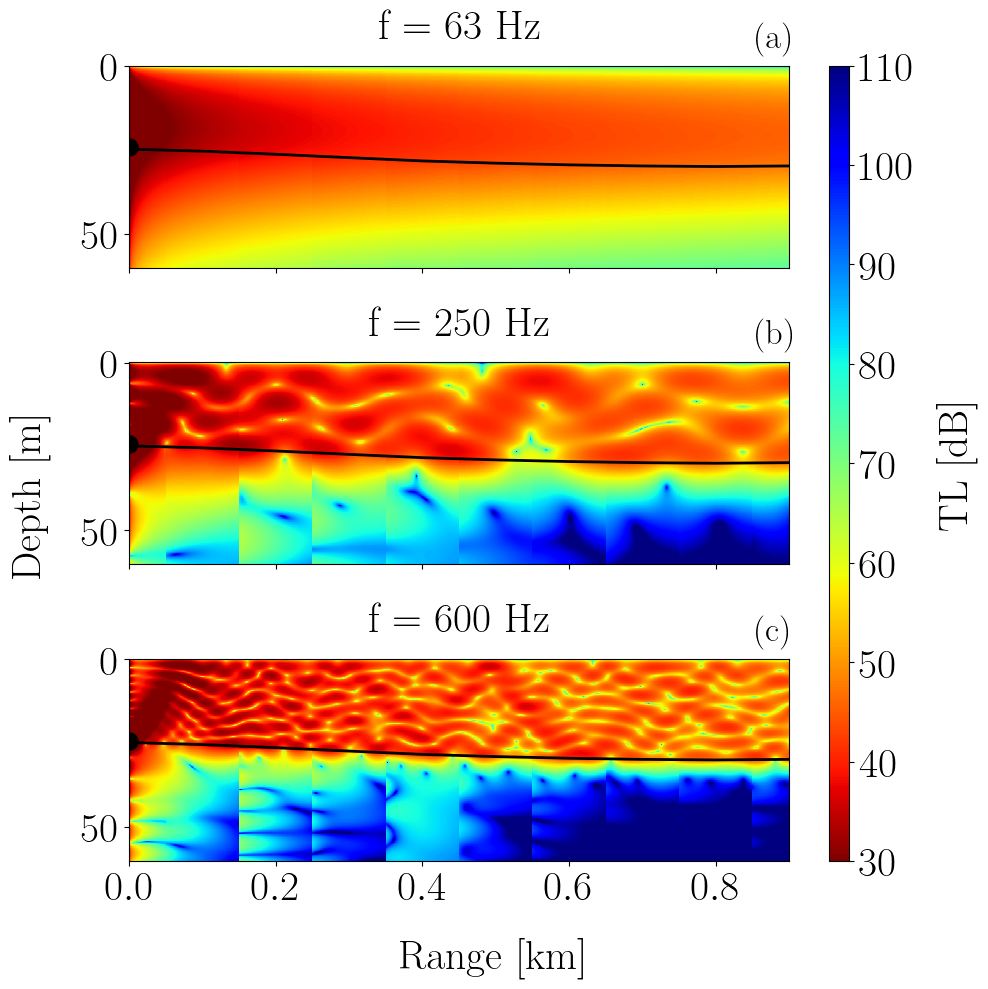

In [71]:
lfig = LargeFigure(size=(16, 7.5))

# Plot tl at a single frequency
tf_demo = ds_tf_demo.tf_real + 1j * ds_tf_demo.tf_imag  # (nf, nz, nr)
freq_plot = demo_freq
p_field = tf_demo.sel(f=freq_plot, method="nearest").values
p_field[(p_field == 0) | np.isnan(p_field)] = 1e-20 
tl = - 20 * np.log10(np.abs(p_field)) 
# tlmax = np.percentile(tl, 95)
# tlmin = np.percentile(tl, 1)

tlmax = 110
tlmin = 30

# Plot TL for each number of modes
fig, axs = plt.subplots(len(freq_plot), figsize=(10, 10), sharex=True)
abcd_labels = ["a", "b", "c"]
for i, fp in enumerate(freq_plot):
    p_field = p_field[i, ...]
    title = f"f = {fp} Hz"

    # Plot TL
    im = axs[i].pcolormesh(
        tf_demo.r * 1e-3,
        tf_demo.z,
        tl[i],
        cmap="jet_r",
        vmin=tlmin,
        vmax=tlmax,
        rasterized=True,
    )

    # Add source position
    if src_depth is not None:
        axs[i].scatter(
            0,
            src_depth,
            color="k",
            marker="o",
            s=150,
        )
    axs[i].set_title(title)
    axs[i].invert_yaxis()

    # Add a, b, c labels
    axs[i].text(
        0.95,
        1.05,
        f"({abcd_labels[i]})",
        transform=axs[i].transAxes,
        fontsize=25,
        fontweight="bold",
        va="bottom",
    )

    # Add bathy
    axs[i].plot(bathy2.bathy_range, bathy2.bathy_depth, color="k", linewidth=2)
    # Limit to bathy range
    axs[i].set_xlim([0, bathy2.bathy_range.max()])

fig.supxlabel("Range [km]")
fig.supylabel("Depth [m]")

# Add common colorbar
cbar = fig.colorbar(im, ax=axs, orientation="vertical", pad=0.05, aspect=40)
cbar.set_label("TL [dB]")


# # Save figure as pdf
# fpath = os.path.join(img_folder_path, f"{name}_tl_3freqs.pdf")
# plt.savefig(fpath)

## Calcul des fonctions de Green du guide d'onde étudié

In [72]:
# Reset kraken properties with much lower output field resolution for memory issues
# Number of receiver depths / ranges (flp file)
lambda_min = g.c0 / src_max_freq
dr = 0.5
dz = 1
nr_flp = int(rmax / dr) + 1
nz_flp = int(rcv_z_max / dz) + 1

kraken_properties = KrakenProperties(
    mode_coupling="coupled",
    mode_addition="coherent",
    n_mode=50,
    nr=nr_flp,
    nz=nz_flp,
    nmedia=nmedia,
    top_hs=top_hs,
    bott_hs=bott_hs,
    att=att,
    medium=medium,
    field=field,
)

# re-Define testcase to update flp props 
k_tc = KrakenTestCase(
    name=name,
    title=title,
    root_dir=tc_root_dir,
    bathy=bathy2,
    domain_properties=domain_properties,
    src_properties=src_properties,
    rcv_properties=rcv_properties,
    kraken_properties=kraken_properties,
)

In [73]:
# Kraken compute otpion
run_kraken = False
# run_kraken = True

In [74]:
run_freq = k_tc.src.freq[
    (k_tc.src.freq >= src_min_freq) & (k_tc.src.freq <= src_max_freq)
]
f_before = src.positive_freq[src.positive_freq < run_freq.min()]
pad_before = f_before.size
f_after = src.positive_freq[src.positive_freq > run_freq.max()]
pad_after = f_after.size

In [75]:
# Evaluate expected cpu time
if run_kraken:
    nproc = N_CORES

    run_freq_cpu_test = run_freq[-nproc :]      # Test with highest frequencies -> worst case scenario
    nf_cpu_test = run_freq_cpu_test.size

    # Run a quick test to estimate cpu time
    t0 = time()
    km = KrakenManager(parallel=False, verbose=True)
    _, _ = km.runkraken(
        env=k_tc.env, flp=k_tc.flp, frequencies=run_freq_cpu_test
    )
    cpu_time = time() - t0

    avg_cpu_time_per_freq = cpu_time / nf_cpu_test
    estimated_cpu_time = avg_cpu_time_per_freq * run_freq.size / nproc

    print(
        f"Max expected cpu time: {estimated_cpu_time / 60:.2f} min for {run_freq.size} frequencies on {nproc} cores"
    )


In [76]:
if run_kraken:
    km = KrakenManager(parallel=True, verbose=True)
    pressure_field, field_pos = km.runkraken(
        env=k_tc.env, flp=k_tc.flp, frequencies=run_freq
    )
    
    pressure_field_real = np.real(pressure_field).astype(np.float32)
    pressure_field_img = np.imag(pressure_field).astype(np.float32)
    # Pad with zeros to get the full frequency band
    pad_tuple = ((pad_before, pad_after),) + ((0, 0),) * (len(pressure_field.shape) - 1)
    pressure_field_real = np.pad(
        pressure_field_real, pad_tuple, mode="constant", constant_values=0
    )
    pressure_field_img = np.pad(
        pressure_field_img, pad_tuple, mode="constant", constant_values=0
    )
    # pressure_field = np.pad(pressure_field, pad_tuple, mode="constant", constant_values=0)

## Sauvergarde des fonctions de transfert du guide d'onde 

In [77]:
if run_kraken:
    # Store pressure field as netcdf using xarray
    # pressure_field = np.squeeze(pressure_field)  # Remove singleton dimensions if any
    pressure_field_real = np.squeeze(pressure_field_real)
    pressure_field_img = np.squeeze(pressure_field_img)

    ds_tf = xr.Dataset(
        data_vars=dict(
            tf_real=(["f", "z", "r"], pressure_field_real),
            tf_imag=(["f", "z", "r"], pressure_field_img),
        ),
        coords=dict(
            f=src.positive_freq,
            z=field_pos["r"]["z"],
            r=field_pos["r"]["r"],
        ),
        attrs=dict(
            title=title,
            description=description,
            # date_created=np.datetime64("now"),
            note=note,
            type="prod",
            fs=src_fs,
            signal_duration=src_signal_duration,
        ),
    )

    # Limit z extension
    zmax = np.ceil(bathy2.bathy_depth.max() + dz)
    ds_tf = ds_tf.sel(z=slice(0, zmax))

    # Save to netcdf
    ds_tf.to_netcdf(tf_prod_fpath)
else:
    # Load transfer functions from netcdf
    ds_tf = xr.open_dataset(tf_prod_fpath)

ds_tf_obs2 = ds_tf

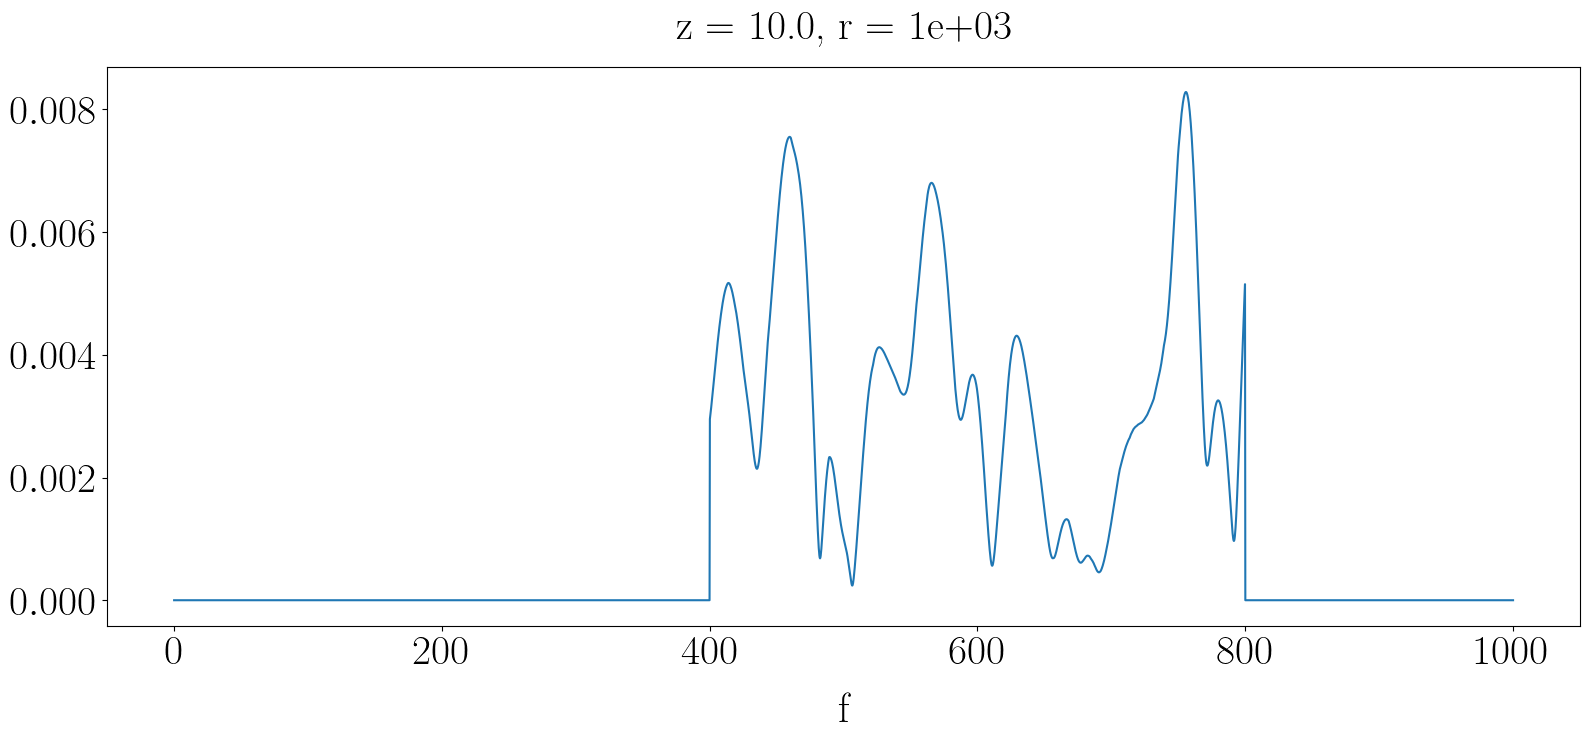

In [78]:
ds_tf_sel = ds_tf_obs2.sel(z=source_depth, r=1000, method="nearest")
tf_sel = ds_tf_sel.tf_real + 1j * ds_tf_sel.tf_imag

np.abs(tf_sel).plot(x="f")
# plt.xlim([src_min_freq, src_max_freq])

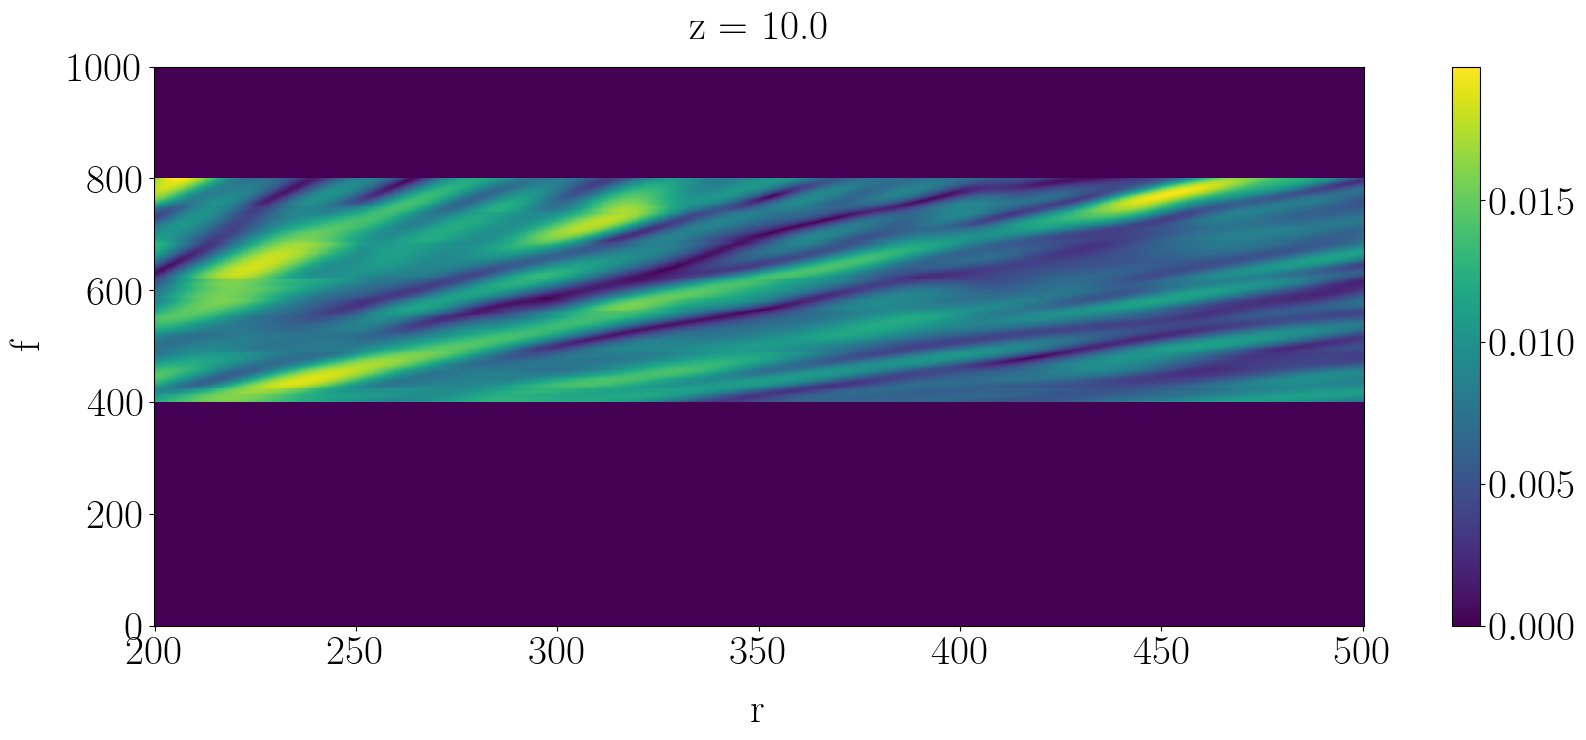

In [79]:
ds_tf_sel = ds_tf.sel(z=source_depth, method="nearest").sel(
    r=slice(200, 500),
)
tf_sel = ds_tf_sel.tf_real + 1j * ds_tf_sel.tf_imag

np.abs(tf_sel).plot(x="r")

# RTF

In [80]:
tf_obs1 = ds_tf_obs1.tf_real + 1j * ds_tf_obs1.tf_imag
tf_obs2 = ds_tf_obs2.tf_real + 1j * ds_tf_obs2.tf_imag

MemoryError: Unable to allocate 1.76 GiB for an array with shape (4097, 32, 3601) and data type float32

In [ ]:
# Select range of interest
# r1 -> distance to obs 1
# r2 -> distance to obs 2

# OBS position
e1 = ds_gps.attrs[f"obs1_e_apriori"]
n1 = ds_gps.attrs[f"obs1_n_apriori"]
e2 = ds_gps.attrs[f"obs2_e_apriori"]
n2 = ds_gps.attrs[f"obs2_n_apriori"]

# Source positions
es = df_seq["emission_interp_e_gps"]
ns = df_seq["emission_interp_n_gps"]

# Distance
r1 = np.sqrt((e1 - es) ** 2 + (n1 - ns) ** 2)
r2 = np.sqrt((e2 - es) ** 2 + (n2 - ns) ** 2)

# Get bounds
r1_min = np.floor(np.min(r1))
r1_max = np.ceil(np.max(r1))
r2_min = np.floor(np.min(r2))
r2_max = np.ceil(np.max(r2))

# r1_max += 200
# r2_max += 200

print(
    f"Distance to OBS 1: rmin = {r1_min:.2f} m, rmax = {r1_max:.2f} m, L = = {r1_max-r1_min:.2f} m"
)
print(
    f"Distance to OBS 2: rmin = {r2_min:.2f} m, rmax = {r2_max:.2f} m,  L = = {r2_max-r2_min:.2f} m"
)

# print(f"Distance OBS 1 - OBS 2 : d_12 = {d_12:.2f} m")
# print(f"Distance OBS 2 - OBS 3 : d_23 = {d_23:.2f} m")

In [ ]:
# Ilustrate dimulation process
lfig = LargeFigure(size=(20, 10))

# Plot tl at a single frequency
tf_demo1 = ds_tf_demo_1.tf_real + 1j * ds_tf_demo_1.tf_imag  # (nf, nz, nr)
tf_demo2 = ds_tf_demo_2.tf_real + 1j * ds_tf_demo_2.tf_imag  # (nf, nz, nr)
freq_plot = 600

# Rcv 1
p_field1 = tf_demo1.sel(f=freq_plot, method="nearest").values
p_field1[(p_field1 == 0) | np.isnan(p_field1)] = 1e-20 
tl1 = - 20 * np.log10(np.abs(p_field1)) 
# Rcv 2
p_field2 = tf_demo2.sel(f=freq_plot, method="nearest").values
p_field2[(p_field2 == 0) | np.isnan(p_field2)] = 1e-20
tl2 = -20 * np.log10(np.abs(p_field2))

tlmax = 90
tlmin = 30

# Plot TL for each number of modes
fig, axs = plt.subplots(1, 2, figsize=(20, 10), sharey=True)
abcd_labels = ["a", "b"]

r_min = [r1_min, r2_min]
r_max = [r1_max, r2_max]
src_depth = [src_depth1, src_depth2]
bathy = [bathy1, bathy2]
tf_demo = [tf_demo1, tf_demo2]
tl = [tl1, tl2]
# Plot TL
for i in [0, 1]:
    im = axs[i].pcolormesh(
        tf_demo[i].r,
        tf_demo[i].z,
        tl[i],
        cmap="jet_r",
        vmin=tlmin,
        vmax=tlmax,
        rasterized=True,
    )

    # Add source position
    axs[i].scatter(
        0,
        src_depth[i],
        color="k",
        marker="o",
        s=150,
    )
    axs[i].set_title(f"From OBS {i+1}")
    # axs[i].invert_yaxis()

    # Add a, b, c labels
    axs[i].text(
        0.95,
        1.02,
        f"({abcd_labels[i]})",
        transform=axs[i].transAxes,
        fontsize=25,
        fontweight="bold",
        va="bottom",
    )

    axs[i].plot(
        # [r_min[i], bathy[i].bathy_range.max() * 1e3],       # TODO : attendtion antenne sort de la bathyrange max ?
        [
            r_min[i],
            r_max[i],
        ],  # TODO : attendtion antenne sort de la bathyrange max ? -> non c'est ok juste il n'y a pas le point suivant de bathy pour tracer (bathy constante par section dans Kraken)
        [source_depth, source_depth],
        linewidth=3,
        linestyle="--",
        marker="x",
        color="k",
        markersize=20,
    )
    # marker="x", size=10, linestyle="--", linewidth=10
    max_depth = 35
    axs[i].fill_between(
        x=bathy[i].bathy_range * 1e3,
        y1=bathy[i].bathy_depth,
        y2=np.ones_like(bathy[i].bathy_depth)*max_depth,
        color="tab:brown"
    )

    # Add bathy
    axs[i].plot(bathy[i].bathy_range*1e3, bathy[i].bathy_depth, color="k", linewidth=2)
    # Limit to bathy range
    # axs[i].set_xlim([0, bathy[i].bathy_range.max()*1e3])
    axs[i].set_ylim([0, max_depth])


axs[i].invert_yaxis()

fig.supxlabel("Range [m]")
fig.supylabel("Depth [m]")

# Add common colorbar
cbar = fig.colorbar(im, ax=axs, orientation="vertical", pad=0.05, aspect=40)
cbar.set_label("TL [dB]")

In [ ]:
tf_demo2

In [ ]:
tf_demo1

In [ ]:
# Define a range vector to interpolate
dr = 1
r1_vect = np.arange(r1_min, r1_max, dr)
r2_vect = np.arange(r2_min, r2_max, dr)

In [ ]:
# Select range of intererest
tf_obs1_range_sel = tf_obs1.sel(f=slice(src_min_freq, src_max_freq)).sel(r=r1_vect, method="nearest").sel(z=source_depth, method="nearest")
tf_obs2_range_sel = (
    tf_obs2.sel(f=slice(src_min_freq, src_max_freq))
    .sel(r=r2_vect, method="nearest")
    .sel(z=source_depth, method="nearest")
)

In [ ]:
# Plot tf module

# Plot TL for each number of modes
fig, axs = plt.subplots(1, 2, figsize=(20, 10), sharey=True)
abcd_labels = ["a", "b"]

tf_obs_range_sel = [tf_obs1_range_sel, tf_obs2_range_sel]
# Plot TL
for i in [0, 1]:
    tf_range_sel = np.abs(tf_obs_range_sel[i])
    im = tf_range_sel.plot(
        x="r",
        cmap="magma",
        ax=axs[i],
        vmin=np.percentile(tf_range_sel, 5),
        vmax=np.percentile(tf_range_sel, 95),
        # cbar_kwargs={"label": r"$\gamma(f, r)$"},
        # cbar_kwargs={"label": r"$\vert H(f, r) \rvert$ [dB]"},
        add_colorbar=False,
    )
    # im = axs[i].pcolormesh(
    #     tf_demo[i].r,
    #     tf_demo[i].z,
    #     tl[i],
    #     cmap="jet_r",
    #     vmin=tlmin,
    #     vmax=tlmax,
    #     rasterized=True,
    # )

    axs[i].set_title(f"From OBS {i+1}")

    # Add a, b, c labels
    axs[i].text(
        0.95,
        1.02,
        f"({abcd_labels[i]})",
        transform=axs[i].transAxes,
        fontsize=25,
        fontweight="bold",
        va="bottom",
    )

    axs[i].set_xlabel("Range [m]")
    axs[i].set_ylabel("")


# fig.supxlabel("Range [m]")
fig.supylabel("Frequency [Hz]")

# Add common colorbar
cbar = fig.colorbar(im, ax=axs, orientation="vertical", pad=0.05, aspect=20)
cbar.set_label(r"$\vert H(f, r) \rvert$")

In [ ]:
# Build RTF 
rtf_12 = tf_obs1_range_sel.values / tf_obs2_range_sel.values
rtf_12_mod = np.abs(rtf_12)

In [ ]:
# pi = 20*np.log10(rtf_12_mod)
# plt.pcolormesh(
#     tf_obs1_range_sel.f,
#     tf_obs1_range_sel.r, 
#     pi.T,
#     cmap="magma",
#     vmin=np.percentile(pi, 5),
#     vmax=np.percentile(pi, 95),
# )


In [ ]:
# Load real data for comparison
fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\event\event_100.nc"
ds = xr.open_dataset(fpath)
dist_rcv = get_dist_to_rcv(ds)
obs_cpa_idx = np.argmin(dist_rcv, axis=1).flatten()
reps = ds.replica_id.values
fig, axs = plot_gamma_along_sequence(
    ds,
    dist_rcv,
    obs_cpa_idx,
    reps,
    replica_id_slice=slice(0, 140),
    fmin=src_min_freq,
    fmax=src_max_freq,
)

In [ ]:
ds_restricted_to_obs1 = ds.isel(h_index=slice(0, 1))

fig, axs = plot_gamma_along_sequence(
    ds_restricted_to_obs1,
    dist_rcv,
    obs_cpa_idx,
    reps,
    replica_id_slice=slice(0, 140),
    fmin=src_min_freq,
    fmax=src_max_freq,
)

# x_box = [src_min_freq, src_min_freq, src_max_freq, src_max_freq]
# y_box = [10, 50, 50, 10]
# axs[0].plot(x_box, y_box)

# print(replica_id_slice_tuple)
# print(replica_id_slice)

import matplotlib.patches as mpatches
rect = mpatches.Rectangle(
    (src_min_freq, replica_id_slice_tuple[0]),
    src_max_freq- src_min_freq,
    replica_id_slice_tuple[1] - replica_id_slice_tuple[0],
    linewidth=5,
    edgecolor="r",
    facecolor="none",
)
axs.add_patch(rect)
# rect = mpatches.Rectangle(
#     (src_min_freq, replica_id_slice_tuple[0]),
#     src_max_freq - src_min_freq,
#     replica_id_slice_tuple[1] - replica_id_slice_tuple[0],
#     linewidth=5,
#     edgecolor="r",
#     facecolor="none",
# )
# axs[1].add_patch(rect)

In [ ]:
fig, axs = plot_gamma_along_sequence(
    ds,
    dist_rcv,
    obs_cpa_idx,
    reps,
    replica_id_slice=replica_id_slice,
    fmin=src_min_freq,
    fmax=src_max_freq,
)

In [ ]:
fmin = src_min_freq
fmax = src_max_freq
id_rcv = 1

In [ ]:
n_rcv = ds.h_index.size
idx_rcv_plot = [idx for idx in ds.h_index.values if idx != ds.reference_receiver_id]

fig, axs = plt.subplots(
    nrows=1, ncols=len(idx_rcv_plot), sharex=True, sharey=False, figsize=(16, 10)
)
ax_mod = axs

rtf_cs_evd_amp = ds.rtf_amp
# Select frequency range
rtf_cs_evd_amp = rtf_cs_evd_amp.sel(f_rtf=slice(src_min_freq, src_max_freq))

# Module
i_ax = 0


# Real data
i_rcv = np.argmin(np.abs(ds.h_index.values - id_rcv))
rtf_cs_evd_amp_rcv = rtf_cs_evd_amp.sel(h_index=id_rcv).sel(
    replica_id=replica_id_slice
)
gamma = 20 * np.log10(rtf_cs_evd_amp_rcv)
gamma.plot(
    x="f_rtf",
    cmap="magma",
    ax=ax_mod[0],
    vmin=np.percentile(gamma, 5),
    vmax=np.percentile(gamma, 95),
    # vmin=np.percentile(gamma_simulation, 5),
    # vmax=np.percentile(gamma_simulation, 95),
    # cbar_kwargs={"label": r"$\gamma(f, r)$"},
    cbar_kwargs={"label": r"$\vert \Pi(f, r) \rvert$ [dB]"},
)

ax_mod[0].set_title(f"OBS {id_rcv}")
ax_mod[0].set_xlabel("")
ax_mod[0].set_ylabel("Replica ID")
ax_mod[0].xaxis.set_major_locator(MaxNLocator(nbins=4))


# Simulation
gamma_simulation = 20*np.log10(rtf_12_mod)
# gamma_simulation = np.flipud(gamma_simulation)
gamma_simulation = xr.DataArray(data=gamma_simulation, coords={"f":tf_obs1_range_sel.f.values, "r":tf_obs1_range_sel.r.values})
gamma_simulation.plot(
    x="f",
    cmap="magma",
    ax=ax_mod[1],
    # vmin=np.percentile(gamma_simulation, 5),
    # vmax=np.percentile(gamma_simulation, 95),
    vmin=np.percentile(gamma, 5),
    vmax=np.percentile(gamma, 95),
    # cbar_kwargs={"label": r"$\gamma(f, r)$"},
    cbar_kwargs={"label": r"$\vert \Pi(f, r) \rvert$ [dB]"},
)

# plt.pcolormesh(
#     tf_obs1_range_sel.f,
#     tf_obs1_range_sel.r,
#     pi.T,
#     cmap="magma",
#     vmin=np.percentile(pi, 5),
#     vmax=np.percentile(pi, 95),
# )

ax_mod[1].set_title(f"OBS {id_rcv}")
ax_mod[1].set_xlabel("")
ax_mod[1].set_ylabel("Range to OBS 1 [m]")
ax_mod[1].xaxis.set_major_locator(MaxNLocator(nbins=4))
ax_mod[1].yaxis.set_inverted(True)

set_subfigures_abc_labels(
    axs=axs, fontsize=14, x_pos=0.015, y_pos=1.01, ha="left", va="bottom"
)
fig.supxlabel("Frequency [Hz]")
# fig.supylabel("Replica ID")

In [ ]:
n_rcv = ds.h_index.size
idx_rcv_plot = [idx for idx in ds.h_index.values if idx != ds.reference_receiver_id]

fig, axs = plt.subplots(
    nrows=1, ncols=1, sharex=True, sharey=False, figsize=(8, 10)
)
ax_mod = axs

rtf_cs_evd_amp = ds.rtf_amp
# Select frequency range
rtf_cs_evd_amp = rtf_cs_evd_amp.sel(f_rtf=slice(src_min_freq, src_max_freq))

# Module
i_ax = 0

# Simulation
gamma_simulation = 20 * np.log10(rtf_12_mod)
gamma_simulation = xr.DataArray(
    data=gamma_simulation,
    coords={"f": tf_obs1_range_sel.f.values, "r": tf_obs1_range_sel.r.values},
)
gamma_simulation.plot(
    x="f",
    cmap="magma",
    ax=ax_mod,
    vmin=np.percentile(gamma, 5),
    vmax=np.percentile(gamma, 95),
    cbar_kwargs={"label": r"$\vert \Pi(f, r) \rvert$ [dB]"},
)

ax_mod.set_title(f"OBS {id_rcv}")
ax_mod.set_xlabel("Frequency [Hz]")
ax_mod.set_ylabel("Range to OBS 1 [m]")
ax_mod.xaxis.set_major_locator(MaxNLocator(nbins=4))
ax_mod.yaxis.set_inverted(True)

## Variation en fonction de la position  

In [ ]:
# Numéro de la réplique pour illustrer les variations de distance
target_rep = 20

In [ ]:
dist_type = "norm_L1_module"
# dist_type = "norm_L2_module"

if dist_type == "norm_L1_module":
    dist_label = r"{L_1}_\text{mod}"
elif dist_type == "norm_L2_module":
    dist_label = r"{L_2}_\text{mod}"

## Données réelles 

In [ ]:
ds_sel = ds.sel(replica_id=replica_id_slice)
spatial_dist_mat = build_dist_matrix(ds_sel)

In [ ]:
ds_sel

In [ ]:
theta_mat_mod = get_bootstrap_dist_matrix(
    ds_=ds_sel, estimator="cs-evd", dist_type="hermitian_angle_module"
)

dL2_mat_mod = get_bootstrap_dist_matrix(
    ds_=ds_sel, estimator="cs-evd", dist_type=dist_type
)

In [ ]:
dL2_mat_mod = dL2_mat_mod / np.max(dL2_mat_mod)
dL2_mat_mod[dL2_mat_mod == 0] = np.nan

In [ ]:
# Quelques lignes à la loupe
target_rep_i = target_rep - ds_sel.replica_id.values[0]
i_ls = [target_rep_i]
fig, axs = plt.subplots(
    nrows=1, ncols=2, sharey=True, figsize=(18, 10), constrained_layout=True
)
ax1, ax2 = axs

vmax = np.nanpercentile(spatial_dist_mat, 75)
im = ax1.pcolormesh(ds_sel.replica_id.values, ds_sel.replica_id.values, spatial_dist_mat, cmap="magma", vmax=vmax)
# fig.colorbar(im, ax=ax1, orientation="vertical", label=r"$d$ [m]")
ax1.set_title(r"$M_{d}$")

clabel = r"$d$ [m]"
fig.colorbar(
    im,
    ax=[ax1],
    label=clabel,
    orientation="vertical",
    fraction=1.0,
    pad=0.07,
)

# vmax = min(np.nanpercentile(theta_mat_mod, 75), np.nanpercentile(theta_mat_mod, 75))

vmax = min(
    np.nanpercentile(10 * np.log10(dL2_mat_mod), 75),
    np.nanpercentile(10 * np.log10(dL2_mat_mod), 75),
)

im = ax2.pcolormesh(
    ds_sel.replica_id.values,
    ds_sel.replica_id.values,
    10 * np.log10(dL2_mat_mod),
    cmap="magma",
    vmax=vmax,
)

ax2.set_title(rf"$M_{{{dist_label}}}$")


clabel = fr"${{{dist_label}}}$ [dB]"
# clabel = r"$\theta_{\text{mod}}$ [°]"
fig.colorbar(
    im,
    ax=[ax2],
    label=clabel,
    orientation="vertical",
    fraction=1.0,
    pad=0.03,
)

fig.supxlabel("Replica i")
fig.supylabel("Replica j")

# Add CPA indication and lines
for ax in axs:
    for k, i_l in enumerate(i_ls):
        ax.axhline(i_l + 0.5, color=color(k), label=rf"$l_{k}$ (j = {i_l})")

ax1.legend()
# ax2.legend()

set_subfigures_abc_labels(
    axs=axs, fontsize=18, x_pos=0.98, y_pos=0.01, ha="right", va="bottom"
)

# fpath = os.path.join(
#     fig_folder,
#     f"bootstrap_theta_mod_cs_evd_deconv.png",
# )

# plt.savefig(fpath)

In [ ]:
print(f"Delta between pos (mean)= {np.mean(np.abs(np.diff(spatial_dist_mat[target_rep_i, :])))} m")
print(f"Delta between pos (max)= {np.max(np.abs(np.diff(spatial_dist_mat[target_rep_i, :])))} m")
print(f"Delta between pos (min)= {np.min(np.abs(np.diff(spatial_dist_mat[target_rep_i, :])))} m")
id = 18
print(f"Dist from rep {id} to {target_rep} : d = {spatial_dist_mat[target_rep_i, id-replica_id_slice_tuple[0]]}")
print(f"Theta rep {id} = {theta_mat_mod[target_rep_i, id-replica_id_slice_tuple[0]]}°")
id = 10
print(f"Dist from rep {id} to {target_rep} : d = {spatial_dist_mat[target_rep_i, id-replica_id_slice_tuple[0]]}")
print(f"Theta rep {id} = {theta_mat_mod[target_rep_i, id-replica_id_slice_tuple[0]]}°")
print(spatial_dist_mat[target_rep_i, :])
fig, axs = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(18, 10))
ax1, ax2= axs

for k, i_l in enumerate(i_ls):
    ax1.plot(
        ds_sel.replica_id.values,
        spatial_dist_mat[i_l, :],
        marker="+",
        color=color(k),
        markersize=15,
        label=rf"$l_{k}$ (j = {i_l + replica_id_slice_tuple[0]})",
    )
    ax2.plot(
        ds_sel.replica_id.values,
        # theta_mat_mod[i_l, :],
        10 * np.log10(dL2_mat_mod[i_l, :]),
        marker="+",
        linestyle="-",
        color=color(k),
        markersize=15,
        label=rf"$l_{k}$ (j = {i_l})",
    )


    il_m1 = i_l - 1
    il_p1 = i_l + 1
    for i_highlight in [il_m1, il_p1]:
        ax1.plot(
            ds_sel.replica_id.values[i_highlight],
            spatial_dist_mat[i_l, :][i_highlight],
            marker="o",
            mec = 'r', 
            mfc = 'none',
            markersize=15,
            # label=rf"$l_{k}$ (j = {i_l + replica_id_slice_tuple[0]})",
        )
        ax2.plot(
            ds_sel.replica_id.values[i_highlight],
            # theta_mat_mod[i_l, :][i_highlight],
            10*np.log10(dL2_mat_mod[i_l, :][i_highlight]),
            marker="o",
            mec="r",
            mfc="none",
            color="r",
            markersize=15,
            # label=rf"$l_{k}$ (j = {i_l})",
        )

ax1.set_ylabel(r"$d$ [m]")
ax2.set_ylabel(fr"${{{dist_label}}}$ [dB]")
# ax2.set_ylabel(r"$\theta_\text{mod}$ [°]")
# ax3.set_ylabel(r"$\theta_\text{mod}$ [°]")

ax1.set_title("Spatial distance")
ax2.set_title("Data distance")
# ax3.set_title("After filtering")

ax1.legend()
# ax2.legend()
fig.supxlabel("Replica ID")


set_subfigures_abc_labels(
    axs=axs, fontsize=18, x_pos=0.99, y_pos=1.01, ha="right", va="bottom"
)

# fpath = os.path.join(
#     fig_folder,
#     f"bootstrap_theta_module_selected_lines_var.png",
# )

# plt.savefig(fpath)

In [ ]:
# Plot one RTF module
rtf_amp_comp = ds_sel.rtf_amp.sel(
    replica_id=slice(target_rep - 1, target_rep+1), h_index=1
)
rtf_amp_comp = 10 * np.log10(rtf_amp_comp)
rtf_amp_comp = rtf_amp_comp.sel(f_rtf=slice(400, 800))

# rtf_amp_comp /= rtf_amp_comp.max()
rtf_amp_comp = rtf_amp_comp.rolling(f_rtf=10, center=True).mean()
plt.figure()
rtf_amp_comp.plot(hue="replica_id")
plt.ylabel(r"$\lvert \Pi \rvert$")
plt.title("OBS 1")

plt.figure()
rtf_amp_comp.plot(y="replica_id", vmin=-5, vmax=5, cmap="magma")

In [ ]:
data_simu = rtf_12
ds_simu = xr.Dataset(
    data_vars=dict(
        rtf_amp=(["f", "r"], np.abs(rtf_12)),
        rtf_phase=(["f", "r"], np.angle(rtf_12)),
    ),
    coords=dict(
        f=tf_obs1_range_sel.f.values,
        r=tf_obs1_range_sel.r.values,
    )
)
ds_simu

In [ ]:
print(ds_simu.r.min(), ds_simu.r.max())

In [ ]:
r_simu = ds_simu.r.values
rr_simu_1, rr_simu_2 = np.meshgrid(r_simu, r_simu)
spatial_dist_mat_simu = np.abs(rr_simu_1 - rr_simu_2)

In [ ]:
dL2_mat_mod_simu = get_bootstrap_dist_matrix_single_component(
    ds=ds_simu.rename({"r": "replica_id"}),
    dist_type=dist_type,
)

In [ ]:
dL2_mat_mod_simu = dL2_mat_mod_simu / np.max(dL2_mat_mod_simu)
dL2_mat_mod_simu[dL2_mat_mod_simu == 0] = np.nan
# dL2_mat_mod_simu += +1e-6    # To avoid zeros
dL2_mat_mod_simu.shape

In [ ]:
# Quelques lignes à la loupe
r_target = r_simu[np.argmin(np.abs(r_simu - r1.values[target_rep_i]))]
r_ls = [r_target]

fig, axs = plt.subplots(
    nrows=1, ncols=2, sharey=True, figsize=(18, 10), constrained_layout=True
)
ax1, ax2 = axs

vmax = np.nanpercentile(spatial_dist_mat_simu, 75)
im = ax1.pcolormesh(
    ds_simu.r.values,
    ds_simu.r.values,
    spatial_dist_mat_simu,
    cmap="magma",
    vmax=vmax,
)
# fig.colorbar(im, ax=ax1, orientation="vertical", label=r"$d$ [m]")
ax1.set_title(r"$M_{d}$")

clabel = r"$d$ [m]"
fig.colorbar(
    im,
    ax=[ax1],
    label=clabel,
    orientation="vertical",
    fraction=1.0,
    pad=0.07,
)

vmax = min(
    np.nanpercentile(10 * np.log10(dL2_mat_mod_simu), 75),
    np.nanpercentile(10 * np.log10(dL2_mat_mod_simu), 75),
)

im = ax2.pcolormesh(
    ds_simu.r.values,
    ds_simu.r.values,
    10 * np.log10(dL2_mat_mod_simu),
    cmap="magma",
    vmax=vmax,
)
ax2.set_title(rf"$M_{{{dist_label}}}$")

clabel = rf"${{{dist_label}}}$ [dB]"
fig.colorbar(
    im,
    ax=[ax2],
    label=clabel,
    orientation="vertical",
    fraction=1.0,
    pad=0.03,
)

fig.supxlabel("Distance to OBS 1 [m]")
fig.supylabel("Distance to OBS 1 [m]")

# Add CPA indication and lines
for ax in axs:
    for k, r_l in enumerate(r_ls):
        ax.axhline(r_l + 0.5, color=color(k), label=rf"$l_{k}$ (r = {r_l:.0f} m)")

ax1.legend()
# ax2.legend()

set_subfigures_abc_labels(
    axs=axs, fontsize=18, x_pos=0.98, y_pos=0.01, ha="right", va="bottom"
)

# fpath = os.path.join(
#     fig_folder,
#     f"bootstrap_theta_mod_cs_evd_deconv.png",
# )

# plt.savefig(fpath)

In [ ]:
# print(f"Delta between pos (mean)= {np.mean(np.abs(np.diff(spatial_dist_mat[target_rep_i, :])))} m")
# print(f"Delta between pos (max)= {np.max(np.abs(np.diff(spatial_dist_mat[target_rep_i, :])))} m")
# print(f"Delta between pos (min)= {np.min(np.abs(np.diff(spatial_dist_mat[target_rep_i, :])))} m")
# id = 18
# print(f"Dist from rep {id} to {target_rep} : d = {spatial_dist_mat[target_rep_i, id-replica_id_slice_tuple[0]]}")
# print(f"Theta rep {id} = {theta_mat_mod[target_rep_i, id-replica_id_slice_tuple[0]]}°")
# id = 10
# print(f"Dist from rep {id} to {target_rep} : d = {spatial_dist_mat[target_rep_i, id-replica_id_slice_tuple[0]]}")
# print(f"Theta rep {id} = {theta_mat_mod[target_rep_i, id-replica_id_slice_tuple[0]]}°")
# print(spatial_dist_mat[target_rep_i, :])
fig, axs = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(18, 10))
ax1, ax2= axs


for k, r_l in enumerate(r_ls):
    i_l = np.argmin(np.abs(r_l - ds_simu.r.values))
    ax1.plot(
        ds_simu.r.values,
        spatial_dist_mat_simu[i_l, :],
        marker="+",
        color=color(k),
        markersize=10,
        label=rf"$l_{k}$ (r = {r_l:.0f}m)",
    )
    ax2.plot(
        ds_simu.r.values,
        10 * np.log10(dL2_mat_mod_simu[i_l, :]),
        marker="+",
        linestyle="-",
        color=color(k),
        markersize=10,
        label=rf"$l_{k}$ (r = {r_l:.0f}m)",
    )

    il_m1 = i_l - 1
    il_p1 = i_l + 1
    for i_highlight in [il_m1, il_p1]:
        ax1.plot(
            ds_simu.r.values[i_highlight],
            spatial_dist_mat_simu[i_l, :][i_highlight],
            marker="o",
            mec="r",
            mfc="none",
            markersize=10,
            # label=rf"$l_{k}$ (j = {i_l + replica_id_slice_tuple[0]})",
        )
        ax2.plot(
            ds_simu.r.values[i_highlight],
            10 * np.log10(dL2_mat_mod_simu[i_l, :])[i_highlight],
            marker="o",
            mec="r",
            mfc="none",
            color="r",
            markersize=10,
            # label=rf"$l_{k}$ (j = {i_l})",
        )

ax1.set_ylabel(r"$d$ [m]")
ax2.set_ylabel(fr"${{{dist_label}}}$ [dB]")
# ax3.set_ylabel(r"$\theta_\text{mod}$ [°]")

ax1.set_title("Spatial distance")
ax2.set_title("Data distance")
# ax3.set_title("After filtering")

ax1.legend()
# ax2.legend()
fig.supxlabel("Distance to OBS 1 [m]")


set_subfigures_abc_labels(
    axs=axs, fontsize=18, x_pos=0.99, y_pos=1.01, ha="right", va="bottom"
)

# fpath = os.path.join(
#     fig_folder,
#     f"bootstrap_theta_module_selected_lines_var.png",
# )

# plt.savefig(fpath)

# plt.xlim(1300, 1400)

In [ ]:
# Plot one RTF module
rtf_amp_comp = ds_simu.rtf_amp.isel(
    r=slice(target_rep - 1, target_rep + 15)
)
rtf_amp_comp = 10 * np.log10(rtf_amp_comp)
rtf_amp_comp = rtf_amp_comp.sel(f=slice(400, 800))

# rtf_amp_comp /= rtf_amp_comp.max()
rtf_amp_comp = rtf_amp_comp.rolling(f=10, center=True).mean()
plt.figure()
rtf_amp_comp.plot(hue="r")
plt.ylabel(r"$\lvert \Pi \rvert$")
plt.title("OBS 1")

plt.figure()
rtf_amp_comp.plot(y="r", vmin=-5, vmax=5, cmap="magma")

In [ ]:
fig, axs = plot_gamma_along_sequence(
    ds,
    dist_rcv,
    obs_cpa_idx,
    reps,
    replica_id_slice=replica_id_slice,
    fmin=src_min_freq,
    fmax=src_max_freq,
)
# axs[0].annotate(
#     "a polar annotation",
#     xy=(400 - 10, target_rep),  # theta, radius
#     xytext=(0.05, 0.05),  # fraction, fraction
#     textcoords="figure fraction",
#     arrowprops=dict(facecolor="black", shrink=0.05),
#     horizontalalignment="left",
#     verticalalignment="bottom",
# )

In [ ]:
# ds_sel_ = ds_sel.sel(replica_id=slice(17, 23))
ds_sel_ = ds_sel

idx_rcv_plot = [
    idx
    for idx in np.atleast_1d(ds_sel.h_index.values)
    if idx != ds_sel.reference_receiver_id
]

ds_not_ref = ds_sel_.sel(h_index=idx_rcv_plot)

In [ ]:
e1 = ds_not_ref.sel(h_index=1).rtf_amp
e3 = ds_not_ref.sel(h_index=3).rtf_amp

mean_e1 = []
mean_e3 = []
plt.figure()
for i, rep_id in enumerate(e1.replica_id):
    e1_rep = e1.sel(replica_id=rep_id)
    e3_rep = e3.sel(replica_id=rep_id)
    mean_e1.append(np.median(e1_rep))
    mean_e3.append(np.median(e3_rep))

    # plt.scatter(np.mean(e1_rep), np.mean(e3_rep), color=color(i))
    # e1_rep_in_perc = e1_rep
    # plt.scatter(e1_rep, e3_rep, color=color(i))


sc = plt.scatter(mean_e1, mean_e3, c=e1.replica_id.values, cmap="jet")
# plt.plot(mean_e1, mean_e3, color="k")

plt.colorbar(sc)
plt.xlabel(r"$\left \lvert \frac{H_1}{H_2} \right \rvert$")
plt.ylabel(r"$\left \lvert \frac{H_3}{H_2} \right \rvert$")

# plt.xlim(0, 200)
# plt.ylim(0, 50)

In [ ]:
e1_rep = e1.sel(replica_id=rep_id)
e1_rep

In [ ]:
rtf_amp_ref = rtf_cs_evd_amp.sel(replica_id=30)


In [ ]:
subsample_factor = 1
r_sel = gamma_simulation.r.values[::subsample_factor]
print(r_sel[1] - r_sel[0])
print(r_sel.size)
gamma_simulation_sel = gamma_simulation.sel(r=r_sel)


n_components = 2        # Dimensionnality of the embeding space

# p  = 2 -> distance euclidienne
n_neighbors = 5

# About picking the size of the neigborhood
# use too few points, and your shortest path has to zig-zag a little
# use too many points and there may be a link the directly connects points that should be far away (on the manifold), but was included in your neighborhood.

p = 2
data_simu = gamma_simulation_sel.values.T  # Input must be (n_sample, n_features)
# Normalize data
data_simu = data_simu / np.max(data_simu)
isomap_simu = manifold.Isomap(n_neighbors=n_neighbors, n_components=n_components, p=p)
data_transformed_simu = isomap_simu.fit_transform(data_simu)

# Normalize
data_transformed_simu /= np.max(data_transformed_simu)

# from sklearn.manifold import TSNE
# # perplexity is related to the number of neighbors, 20 leads to a continuous line in 2D
# perplexity = 20

# data_simu = gamma_simulation_sel.values.T  # Input must be (n_sample, n_features)
# # Normalize data
# data_simu = data_simu / np.max(data_simu)
# tsne_simu = TSNE(
#     n_components=n_components,
#     learning_rate="auto",
#     init="random",
#     perplexity=perplexity,
# )
# data_transformed_simu = tsne_simu.fit_transform(data_simu)

In [ ]:
print(data_simu.shape)
gamma_simulation

In [ ]:
if n_components == 2:
    sc = plt.scatter(
        data_transformed_simu[:, 0],
        data_transformed_simu[:, 1],
        c=gamma_simulation_sel.r.values,
        cmap="jet",
    )
    plt.colorbar(sc, label="Range to OBS 1 [m]")
    plt.xlabel(r"$\Phi_1$")
    plt.ylabel(r"$\Phi_2$")

elif n_components == 1:

    sc = plt.scatter(
        gamma_simulation_sel.r.values,
        data_transformed_simu[:, 0],
        # data_transformed_simu[:, 1],
        # c=tf_obs1_range_sel.r.values,
        # cmap="jet",
    )
    # plt.colorbar(sc, label="Range to OBS 1 [m]")
    plt.ylabel(r"$\Phi_1$")
    plt.xlabel("Range to OBS 1 [m]")

    # sc = plt.scatter(
    #     np.arange(data_transformed_simu[:, 0].size),
    #     data_transformed_simu[:, 0],
    #     # data_transformed_simu[:, 1],
    #     c=tf_obs1_range_sel.r.values,
    #     cmap="jet",
    # )
    # plt.colorbar(sc, label="Range to OBS 1 [m]")
    # plt.ylabel(r"$\Phi_1$")
    # plt.ylabel(r"$\Phi_2$")

In [ ]:
p = 2
n_neighbors = 5
n_components = 1        # Dimensionnality of the embeding space 

subsample_factor = 1
r_sel = gamma_simulation.r.values[::subsample_factor]
print(r_sel[1] - r_sel[0])
print(r_sel.size)
gamma_simulation_sel = gamma_simulation.sel(r=r_sel)
data_simu = gamma_simulation_sel.values.T  # Input must be (n_sample, n_features)
data_simu = data_simu / np.max(data_simu)

# data_simu = gamma_simulation.values.T      # Input must be (n_sample, n_features)
# # Normalize data
# data_simu = data_simu / np.max(data_simu)
isomap_simu = manifold.Isomap(n_neighbors=n_neighbors, n_components=n_components, p=p)
data_transformed_simu = isomap_simu.fit_transform(data_simu)

# Normalize 
data_transformed_simu[:, 0] /= np.max(data_transformed_simu[:, 0])

# t-SNE
# perplexity = 20
# # Normalize data
# tsne_simu = TSNE(
#     n_components=n_components,
#     learning_rate="auto",
#     init="random",
#     perplexity=perplexity,
# )
# data_transformed_simu = tsne_simu.fit_transform(data_simu)

In [ ]:
# gamma_simulation_sel.r.values.shape
data_transformed_simu[:, 0].shape

In [ ]:
if n_components == 2:
    sc = plt.scatter(
        data_transformed_simu[:, 0],
        data_transformed_simu[:, 1],
        c=gamma_simulation_sel.r.values,
        cmap="jet",
    )
    plt.colorbar(sc, label="Range to OBS 1 [m]")
    plt.xlabel(r"$\Phi_1$")
    plt.ylabel(r"$\Phi_2$")

elif n_components == 1:

    sc = plt.scatter(
        gamma_simulation_sel.r.values,
        # data_transformed_simu[:, 0],
        data_transformed_simu[:, 0],
        # data_transformed_simu[:, 1],
        # c=tf_obs1_range_sel.r.values,
        # cmap="jet",
    )
    # plt.colorbar(sc, label="Range to OBS 1 [m]")
    plt.ylabel(r"$\Phi_1$")
    plt.xlabel("Range to OBS 1 [m]")

    # sc = plt.scatter(
    #     np.arange(data_transformed_simu[:, 0].size),
    #     data_transformed_simu[:, 0],
    #     # data_transformed_simu[:, 1],
    #     c=tf_obs1_range_sel.r.values,
    #     cmap="jet",
    # )
    # plt.colorbar(sc, label="Range to OBS 1 [m]")
    # plt.ylabel(r"$\Phi_1$")
    # plt.ylabel(r"$\Phi_2$")

In [ ]:
plt.figure(figsize=(8, 10))
sc = plt.scatter(
    gamma_simulation_sel.r.values,
    # data_transformed_simu[:, 0],
    data_transformed_simu[:, 0],
    # data_transformed_simu[:, 1],
    # c=tf_obs1_range_sel.r.values,
    # cmap="jet",
)
# plt.colorbar(sc, label="Range to OBS 1 [m]")
plt.ylabel(r"$\Phi_1$")
plt.xlabel("Range to OBS 1 [m]")


In [ ]:
r_simu = ds_simu.r
r_target = r_simu.sel(r=r1.values[target_rep_i], method="nearest").values
dist_to_target = np.abs(r_simu - r_target)

phi1 = data_transformed_simu[:, 0]
idx_target = np.argmin(dist_to_target.values)
phi1_target = phi1[idx_target]
# dist_to_target_dataspace = 10 * np.log10(np.abs(phi1 - phi1_target))
dist_to_target_dataspace = np.abs(phi1 - phi1_target)

fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(16, 10), sharex=True)
axs[0].plot(
    r_simu, dist_to_target,
)
axs[1].plot(
    r_simu,
    dist_to_target_dataspace,
)
fig.supxlabel("Distance to OBS 1 [m]")
axs[0].set_ylabel("d [m]")
# axs[1].set_ylabel("Distance in data space")
# axs[1].set_ylabel(r"$\lvert \Phi_1(r) - \Phi_1(r_0) \rvert$ [dB]")
axs[1].set_ylabel(r"$\lvert \Phi_1(r) - \Phi_1(r_0) \rvert$")

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(18, 10))
ax1, ax2 = axs


for k, r_l in enumerate(r_ls):
    # Simu
    i_l = np.argmin(np.abs(r_l - ds_simu.r.values))
    ax1.plot(
        ds_simu.r.values,
        spatial_dist_mat_simu[i_l, :],
        # marker="+",
        color=color(0),
        # markersize=5,
        label=f"Simulation",
    )
    ax2.plot(
        ds_simu.r.values,
        10 * np.log10(dL2_mat_mod_simu[i_l, :] / np.nanmax(dL2_mat_mod_simu[i_l, :])),
        # dL2_mat_mod_simu[i_l, :] / np.max(dL2_mat_mod_simu[i_l, :]),
        # marker="+",
        linestyle="-",
        color=color(0),
        # markersize=10,
        label=f"Simulation",
    )
    # Simu ISOMAP
    ax2.plot(
        ds_simu.r.values,
        10 * np.log10(np.abs(phi1 - phi1_target) / np.nanmax(np.abs(phi1 - phi1_target))),
        # np.abs(phi1 - phi1_target) / np.max(np.abs(phi1 - phi1_target)),
        # marker="+",
        linestyle="-",
        color=color(1),
        # markersize=10,
        label=f"Simulation (ISOMAP projection, d = 1)",
    )
    # 10 * np.log10(np.abs(phi1 - phi1_target))
    # Real data
    i_l = i_ls[k]
    ax1.plot(
        r1,
        spatial_dist_mat[i_l, :],
        marker="+",
        color=color(2),
        markersize=10,
        label=f"Real data",
    )
    ax2.plot(
        r1,
        10 * np.log10(dL2_mat_mod[i_l, :] / np.nanmax(dL2_mat_mod[i_l, :])),
        # dL2_mat_mod[i_l, :] / np.nanmax(dL2_mat_mod[i_l, :]),
        marker="+",
        linestyle="-",
        color=color(2),
        markersize=10,
        # label=rf"$l_{k}$ (r = {r_l:.0f}m)",
        label=rf"Real data",
    )

    il_m1 = i_l - 1
    il_p1 = i_l + 1
    # for i_highlight in [il_m1, il_p1]:
    #     ax1.plot(
    #         data_simu.r.values[i_highlight],
    #         spatial_dist_mat_simu[i_l, :][i_highlight],
    #         marker="o",
    #         mec="r",
    #         mfc="none",
    #         markersize=15,
    #         # label=rf"$l_{k}$ (j = {i_l + replica_id_slice_tuple[0]})",
    #     )
    #     ax2.plot(
    #         data_simu.r.values[i_highlight],
    #         10 * np.log10(dL2_mat_mod_simu[i_l, :])[i_highlight],
    #         marker="o",
    #         mec="r",
    #         mfc="none",
    #         color="r",
    #         markersize=15,
    #         # label=rf"$l_{k}$ (j = {i_l})",
    #     )

ax1.set_ylabel(r"$d$ [m]")
ax2.set_ylabel(fr"${{{dist_label}}}$ [dB]")
# ax2.set_ylabel(rf"${{{dist_label}}}$")

# ax3.set_ylabel(r"$\theta_\text{mod}$ [°]")

ax1.set_title("Spatial distance")
ax2.set_title("Data distance")
# ax3.set_title("After filtering")

ax1.legend(fontsize=20)
ax2.legend(fontsize=20)
fig.supxlabel("Distance to OBS 1 [m]")


set_subfigures_abc_labels(
    axs=axs, fontsize=18, x_pos=0.99, y_pos=1.01, ha="right", va="bottom"
)

# fpath = os.path.join(
#     fig_folder,
#     f"bootstrap_theta_module_selected_lines_var.png",
# )

# plt.savefig(fpath)

# plt.xlim(1600, 1800)

In [ ]:
data = gamma.values.T  # Input must be (n_sample, n_features)
data = data / np.max(data_simu)

real_data_transformed_simu = isomap_simu.fit_transform(data)
real_data_dist_to_obs1 = r1
# real_data_transformed_simu

In [ ]:
if n_components == 2:
    sc = plt.scatter(
        data_transformed_simu[:, 0],
        data_transformed_simu[:, 1],
        c=gamma_simulation_sel.r.values,
        cmap="jet",
    )
    plt.colorbar(sc, label="Range to OBS 1 [m]")
    plt.xlabel(r"$\Phi_1$")
    plt.ylabel(r"$\Phi_2$")

elif n_components == 1:

    sc = plt.scatter(
        gamma_simulation_sel.r.values,
        data_transformed_simu[:, 0],
    )

    plt.ylabel(r"$\Phi_1$")
    plt.xlabel("Range to OBS 1 [m]")

    plt.scatter(real_data_dist_to_obs1, real_data_transformed_simu)

In [ ]:
isomap = manifold.Isomap(n_neighbors=n_neighbors, n_components=n_components, p=p)
data_transformed = isomap.fit_transform(data)

In [ ]:
print(data.shape)
gamma

In [ ]:
if n_components == 2:
    sc = plt.scatter(
        data_transformed[:, 0],
        data_transformed[:, 1],
        # c=tf_obs1_range_sel.r.values,
        c=gamma.replica_id.values,
        cmap="jet",
    )
    plt.colorbar(sc, label="Replica ID")
    plt.xlabel(r"$\Phi_1$")
    plt.ylabel(r"$\Phi_2$")

elif n_components == 1:

    sc = plt.scatter(
        gamma.replica_id.values,
        data_transformed[:, 0],
    )
    # plt.colorbar(sc, label="Range to OBS 1 [m]")
    plt.ylabel(r"$\Phi_1$")
    plt.xlabel("Replica ID")


# sc = plt.scatter(
#     np.arange(data_transformed[:, 0].size),
#     data_transformed[:, 0],
#     # data_transformed_simu[:, 1],
#     c=gamma.replica_id.values,
#     cmap="jet",
# )
# plt.colorbar(sc, label="Replica ID")
# plt.ylabel(r"$\Phi_1$")
# # plt.ylabel(r"$\Phi_2$")


# sc = plt.scatter(
#     data_transformed[:, 0],
#     data_transformed[:, 1],
#     c=gamma.replica_id.values,
#     cmap="jet"
# )
# plt.colorbar(sc, label="Replica ID")
# plt.xlabel(r"$\Phi_1$")
# plt.ylabel(r"$\Phi_2$")

In [ ]:
x = gamma.replica_id.values
y = data_transformed[:, 0]


# Apply polynomial fitting
poly_order_start = 14
poly_order_stop = 16
poly_order_step = 1
poly_orders = np.arange(poly_order_start, poly_order_stop+poly_order_step, step=poly_order_step)

plt.figure()
for poly_order in poly_orders:
# poly_order = 15

    z = np.polyfit(x, y, poly_order)
    # print(z)

    p = np.poly1d(z)

    err = p(x) - y 
    rmse = np.sqrt(np.mean(err**2))
    # print(rmse)

    rep_poly = np.linspace(gamma.replica_id.min(), gamma.replica_id.max(), 1000)

    sc = plt.scatter(
        gamma.replica_id.values,
        data_transformed[:, 0],
    )
    plt.plot(rep_poly, p(rep_poly), label=f"order = {poly_order}, RMSE = {rmse}")
    # plt.colorbar(sc, label="Range to OBS 1 [m]")

plt.legend(fontsize=12)
plt.ylabel(r"$\Phi_1$")
plt.xlabel("Replica ID")

In [ ]:
x = gamma.replica_id.values
y = data_transformed[:, 0]

x_simu = np.arange(gamma_simulation_sel.r.size) + np.min(x)
y_simu = data_transformed_simu[:, 0]


# Apply polynomial fitting
poly_order = 15


plt.figure()
z = np.polyfit(x, y, poly_order)
z_simu = np.polyfit(x_simu, y_simu, poly_order)
# print(z)

p = np.poly1d(z)
p_simu = np.poly1d(z_simu)

err = p(x) - y
rmse = np.sqrt(np.mean(err**2))
# print(rmse)

rep_poly = np.linspace(gamma.replica_id.min(), gamma.replica_id.max(), 1000)
rep_poly_simu = np.linspace(np.min(x_simu), np.max(x_simu), 1000)
sc = plt.scatter(
    x, 
    y,
    color=color(0)
)
# sc_simu = plt.scatter(x_simu, y_simu, color=color(1))


plt.plot(rep_poly, p(rep_poly), label=f"order = {poly_order}, RMSE = {rmse}", color=color(0))
# plt.plot(
#     rep_poly_simu,
#     p_simu(rep_poly_simu),
#     label=f"order = {poly_order}, RMSE = {rmse}",
#     color=color(1),
# )

# plt.colorbar(sc, label="Range to OBS 1 [m]")

plt.ylabel(r"$\Phi_1$")
plt.xlabel("Replica ID")

### Comparaison données réelles vs simulation avec le même échantillonnage 

In [ ]:
p = 2
n_neighbors = 5
n_components = 1  # Dimensionnality of the embeding space

# Subsample simulation data at real data positions
gamma_simulation_sel = gamma_simulation.sel(r=r1.values, method="nearest")
data_simu = gamma_simulation_sel.values.T  # Input must be (n_sample, n_features)
data_simu = data_simu / np.max(data_simu)
# Compute Isomap for synthetic data
isomap_simu = manifold.Isomap(n_neighbors=n_neighbors, n_components=n_components, p=p)
data_transformed_simu = isomap_simu.fit_transform(data_simu)

# Compute Isomap for real data
isomap = manifold.Isomap(n_neighbors=n_neighbors, n_components=n_components, p=p)
data_transformed = isomap.fit_transform(data)

In [ ]:
# Real data
x = r1.values
y = data_transformed[:, 0]
# Synthetic data
x_simu = gamma_simulation_sel.r.values
y_simu = data_transformed_simu[:, 0]

# Normalize coordinates for comparison
y /= np.max(y)
y_simu /= np.max(y_simu)

# Apply polynomial fitting
poly_order = 20
z = np.polyfit(x, y, poly_order)
z_simu = np.polyfit(x_simu, y_simu, poly_order)

p = np.poly1d(z)
p_simu = np.poly1d(z_simu)

err = p(x) - y
rmse = np.sqrt(np.mean(err**2))
print(rmse)

rep_poly = np.linspace(np.min(x), np.max(x), 1000)
rep_poly_simu = np.linspace(np.min(x_simu), np.max(x_simu), 1000)

plt.figure()

# Plot
# sc = plt.scatter(x, y, color=color(2))
# sc_simu = plt.scatter(x_simu, y_simu, color=color(1))

plt.plot(x, y, color=color(0), marker="o", markersize=5, label="Real data")
plt.plot(x_simu, y_simu, color=color(1), marker="o", markersize=5, label="Simulation")

# plt.plot(
#     rep_poly, p(rep_poly), label=f"order = {poly_order}, RMSE = {rmse}", color=color(2)
# )
# plt.plot(
#     rep_poly_simu,
#     p_simu(rep_poly_simu),
#     label=f"order = {poly_order}, RMSE = {rmse}",
#     color=color(1),
# )

# plt.colorbar(sc, label="Range to OBS 1 [m]")
plt.legend()
plt.ylabel(r"$\Phi_1$")
plt.xlabel("Range to OBS 1 [m]")

In [ ]:
# print(r1.values - gamma_simulation_sel.r.values)

In [ ]:
# # Compute length along poly
# # dy = p(x)[1:] - p(x)[:-1]
# # dx = x[1:] - x[:-1]
# # ds = dy / dx

# # s = ds.sum()
# # print(s)

# def compute_s_distance(x0, x1, poly, xpoly):
#     dx = xpoly[1:] - xpoly[:-1]
#     # print(dx)
#     y = poly(xpoly)
#     dy = y[1:] - y[:-1]
#     # print(dy)

#     ds = np.abs(dy / dx)
#     # print(ds)
#     idx_x0 = np.argmin(np.abs(xpoly - x0))
#     idx_x1 = np.argmin(np.abs(xpoly - x1))
#     ds_ = ds[idx_x0:idx_x1]
#     s = np.sum(ds_)
#     return s 

In [ ]:
# xpoly = np.linspace(gamma.replica_id.min(), gamma.replica_id.max(), 1000)
# id_rep0 = 10
# id_rep1 = 19
# s = compute_s_distance(x0=id_rep0, x1=id_rep1, poly=p, xpoly=xpoly)
# print(f"Distance bewteen rep {id_rep0} and {id_rep1}: s = {s}")


# Visualisation autres (leftovers)

## Visualisation du signal propagé

In [ ]:
# # run_this_section = False
# run_this_section = True

In [ ]:
# rmin_visu = 0 * 1e3  # Minimum range for visualization
# rmax_visu = bathy.bathy_range.max() * 1e3  # Maximum range for visualization
# ds_tf_pulse = ds_tf.sel(r=slice(rmin_visu, rmax_visu))  # Select receivers at required range
# rcv_range = ds_tf_pulse.r.values

# delays = rcv_range / g.c0
# rcv_depth = np.linspace(k_tc.flp.rcv_z_min, k_tc.flp.rcv_z_max, k_tc.flp.n_rcv_z)

In [ ]:
# sig_fpath = os.path.join(data_folder_path, f"propagated_pulse_{seq_id}.nc")
# if run_this_section:
#     # Source spectrum
#     Sf = src.positive_spectrum

#     # Derive delay for each receiver
#     tau_rcv = ds_tf_pulse.r.min().values / g.c0
#     # tau_rcv = target_range / g.c0

#     tf = ds_tf_pulse.tf_real + 1j * ds_tf_pulse.tf_imag  # (nf, nz, nr)

#     # Derive received spectrum (Y = SH)
#     k0 = 2 * np.pi * ds_tf_pulse.f.values / g.c0
#     norm_factor = np.exp(1j * k0) / (4 * np.pi)

#     # # Derive delay factor to take into account the propagation time
#     delay_rcv = np.exp(1j * 2 * np.pi * tau_rcv * ds_tf_pulse.f.values)  # (nf,)

#     y_f = mult_along_axis(tf, Sf * norm_factor * delay_rcv, axis=0)

#     nfft_inv = (
#         4 * src.nfft
#     )  # according to Jensen et al. (2000) p.616 : dt < 1 / (8 * fmax) for visual inspection of the propagated pulse
#     T_tot = 1 / src.df
#     dt = T_tot / nfft_inv
#     time_vector = np.arange(0, T_tot, dt)

#     # FFT inv to get signal
#     y_t = np.fft.irfft(y_f, axis=0, n=nfft_inv)  # (nt, nz, nr)
#     y_t = np.real(y_t)  # Keep only real part

#     # Build dataset to save
#     ds_sig = xr.Dataset(
#         coords=dict(
#             t=time_vector,
#             z=ds_tf_pulse.z,
#             r=ds_tf_pulse.r,
#         ),
#         data_vars=dict(
#             s=(["t", "z", "r"], y_t),
#         ),
#     )

#     # Save dataset
#     ds_sig.to_netcdf(sig_fpath)
# else:
#     # Load dataset
#     ds_sig = xr.open_dataset(sig_fpath)

In [ ]:
# range_plot = np.array([1*1e3, 1.5 * 1e3])

# dz = 5
# depth_plot = np.arange(dz, bathy.bathy_depth.max(), dz)  # Depths to plot

# # Scale for visualization
# max_amplitude = ds_sig.s.max().values
# alpha_dilatation = 100 * dz 
# ds_sig["s"] = ds_sig.s / max_amplitude * alpha_dilatation

# # # Roll over time axis to start at zero
# # tau_roll = (
# #     range_plot[0] - ds_sig.r.min().values
# # ) / g.c0  # Roll time axis to start at zero
# # ts = ds_sig.t.diff("t").values[0]
# # idx_tau_roll = int(tau_roll / ts)
# # sig_roll = ds_sig.s.roll(t=-idx_tau_roll, roll_coords=False)
# sig_roll = ds_sig.s

# z_offset = depth_plot[1] - depth_plot[0]
# for ir, r in enumerate(range_plot):
#     plt.figure(figsize=(8, 12))
#     for iz, z in enumerate(depth_plot):
#         sig = sig_roll.sel(z=z, r=r, method="nearest") + (iz + 1) * z_offset
#         if z == src_depth:
#             sig.plot(color="r", label="Source depth")
#         else:
#             sig.plot(color="k")

#     # Revert y-axis
#     ax = plt.gca()
#     ax.invert_yaxis()
#     plt.xlim([r/1500-0.15, r/1500+0.15])
#     # plt.xlabel(f"Time  t - r/{g.c0} [s]")
#     plt.xlabel("Time [s]")
#     plt.ylabel("Depth [m]")
#     plt.title(
#         "",
#     )
#     # Save figure as pdf
#     fpath = os.path.join(img_folder_path, f"{name}_received_signals_{range_plot[0]}m.pdf")
#     plt.savefig(fpath)

In [ ]:
# z_plot = 10
# r_plot =  bathy.bathy_range.max() * 1e3
# # r_plot=200
# print(f"rplot = {r_plot}m")
# ts = ds_sig.t.diff("t").values[0]

# # tau_roll = (r_plot - ds_sig.r.min().values) / g.c0  # Roll time axis to start at zero
# # idx_tau_roll = tau_roll / ts
# # idx_tau_roll = idx_tau_roll.astype(int)

# # sig = ds_sig.s.sel(r=r_plot, z=z_plot, method="nearest")
# # sig = sig / sig.max().values
# # sig_roll = sig.roll(t=-idx_tau_roll, roll_coords=False)
# sig = ds_sig.s.sel(r=r_plot, z=z_plot, method="nearest")
# print(f"z = {sig.z.values}m, r = {sig.r.values}m")
# sig_roll = sig / sig.max().values
# sig_roll.plot(color="k")
# plt.xlabel(f"Time  t - r/{g.c0} [s]")
# plt.ylabel("Amplitude")
# plt.xlim([sig.r.values / 1500 - 0.15, sig.r.values / 1500 + 0.15])

In [ ]:
# import scipy.signal as sp

# time_vector = ds_sig.t.values
# fs = 1 / ts

# # Limit signal
# t_win_idx = (time_vector <= 1.6) & (time_vector >= 1.15)
# t_win = time_vector[t_win_idx]
# kraken_win = sig_roll.values[t_win_idx]

# # Decimate to 1000 Hz for better stft visualization
# kraken_win_decimated = sp.decimate(kraken_win, 4)


# plt.figure()
# plt.plot(t_win, kraken_win)

# t_win_decimated = t_win[::4]
# fs_kraken_decimated = fs / 4
# plt.scatter(t_win_decimated, kraken_win_decimated, color="red", s=10)

In [ ]:
# nperseg = 31
# nfft = 2024
# noverlap = int(nperseg * 0.95)

# f, t, Sxx = sp.stft(
#     kraken_win_decimated,
#     fs=fs_kraken_decimated,
#     nperseg=nperseg,
#     noverlap=noverlap,
#     nfft=nfft,
#     scaling="psd",
# )


# Sxx_db = 20 * np.log10(abs(Sxx))

# plt.figure()
# plt.pcolormesh(
#     t,
#     f,
#     20 * np.log10(abs(Sxx)),
#     cmap="jet",
#     vmin=np.percentile(Sxx_db, 75),
#     vmax=np.percentile(Sxx_db, 99.5),
# )

In [ ]:
# # Derive prms
# p = sig_roll
# t_win = 100
# # print(f"Window size for RMS: {t_win} samples")
# print(f"Window duration for RMS: {t_win * ts:.2f} s")
# p2_roll = (p**2).rolling(t=t_win, center=True).mean()  
# p_rms = np.sqrt(p2_roll)

# # Plot p_rms
# plt.figure()
# p_rms.plot(color="k")
# plt.xlabel(f"Time  t - r/{g.c0} [s]")
# plt.ylabel("RMS pressure")
# plt.title("")
# # plt.xlim([0, 4])  # Cropp the end to avoid wrapped around signal artefacts

In [ ]:
# # Derive SPL
# # p_rms /= p_rms.max().values
# spl = 20 * np.log10(p_rms / g.p0)

# # Plot spl
# spl.plot(color="k")

# # Add threshold line
# threshold = -30  # Threshold in dB
# th = np.max(spl).values + threshold
# plt.axhline(
#     y=th,
#     color="r",
#     linestyle="--",
#     linewidth=1,
#     label=f"{threshold} dB",
# )

# # plt.xlim([0, 4])  # Cropp the end to avoid wrapped around signal artefacts
# plt.xlabel(f"Time  t - r/{g.c0} [s]")
# plt.ylabel("SPL [dB re 1uPa]")
# plt.legend()
# plt.title("")

# # # Save figure as pdf
# # fpath = os.path.join(img_folder_path, f"{name}_ir_spl_{r_plot}m.pdf")
# # plt.savefig(fpath)

## Visualisation de la réponse impulsionnelle

In [ ]:
# # run_this_section = False
# run_this_section = True

In [ ]:
# rmin_visu = 0 * 1e3  # Minimum range for visualization
# rmax_visu = bathy.bathy_range.max() * 1e3  # Maximum range for visualization
# ds_tf_ir = ds_tf.sel(
#     r=slice(rmin_visu, rmax_visu)
# )  # Select receivers at required range
# rcv_range = ds_tf_ir.r.values

# delays = rcv_range / g.c0
# rcv_depth = np.linspace(k_tc.flp.rcv_z_min, k_tc.flp.rcv_z_max, k_tc.flp.n_rcv_z)

In [ ]:
# ir_fpath = os.path.join(data_folder_path, "ir.nc")

# if run_this_section:
#     # Source spectrum
#     Sf = src.positive_spectrum
#     # Set Sf to unity to get the impulse response 
#     Sf[:] = 1

#     # Derive delay for each receiver
#     tau_rcv = ds_tf_ir.r.min().values / g.c0
#     # tau_rcv = target_range / g.c0

#     tf = ds_tf_ir.tf_real + 1j * ds_tf_ir.tf_imag  # (nf, nz, nr)

#     # Derive received spectrum (Y = SH)
#     k0 = 2 * np.pi * ds_tf_ir.f.values / g.c0
#     norm_factor = np.exp(1j * k0) / (4 * np.pi)

#     # # Derive delay factor to take into account the propagation time
#     delay_rcv = np.exp(1j * 2 * np.pi * tau_rcv * ds_tf_ir.f.values)  # (nf,)

#     y_f = mult_along_axis(tf, Sf * norm_factor * delay_rcv, axis=0)

#     nfft_inv = (
#         4 * src.nfft
#     )  # according to Jensen et al. (2000) p.616 : dt < 1 / (8 * fmax) for visual inspection of the propagated pulse
#     T_tot = 1 / src.df
#     dt = T_tot / nfft_inv
#     time_vector = np.arange(0, T_tot, dt)

#     # FFT inv to get signal
#     y_t = np.fft.irfft(y_f, axis=0, n=nfft_inv)  # (nt, nz, nr)
#     y_t = np.real(y_t)  # Keep only real part

#     # Build dataset to save
#     ds_ir = xr.Dataset(
#         coords=dict(
#             t=time_vector,
#             z=ds_tf_ir.z,
#             r=ds_tf_ir.r,
#         ),
#         data_vars=dict(
#             s=(["t", "z", "r"], y_t),
#         ),
#     )

#     # Save dataset
#     ds_ir.to_netcdf(ir_fpath)
# else:
#     ds_ir = xr.open_dataset(ir_fpath)

In [ ]:
# z_plot = bathy.bathy_depth.max() - 1
# r_plot = bathy.bathy_range.max() * 1e3

# ts = ds_ir.t.diff("t").values[0]
# tau_roll = r_plot / g.c0 # Roll time axis to start at zero 

# print(f"R = {r_plot}m, tau = {tau_roll}s")
# idx_tau_roll = tau_roll / ts
# idx_tau_roll = idx_tau_roll.astype(int)

# # Scale for visualization
# max_amplitude = ds_ir.s.max().values
# # alpha_dilatation = 1 * r_offset
# # ds_ir["s"] = ds_ir.s / max_amplitude * alpha_dilatation

# plt.figure(figsize=(8, 12))
# # Get ir at rplot, zplot
# sig = ds_ir.s.sel(r=r_plot, z=z_plot, method="nearest")

# # # Roll over time axis for current range
# # sig_roll = sig.roll(t=-idx_tau_roll, roll_coords=False)
# # sig_roll.plot(color="k")
# sig.plot(color="k")

# # plt.xlabel(f"Time  t - r/{g.c0} [s]")
# plt.xlabel("Time [s]")
# plt.ylabel("Range [m]")
# plt.xlim([0.5, 1.5])

# fs = int(1 / ts)
# from scipy.io import wavfile
# root_wav_save = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\extracted_signal_for_warping"
# fpath = os.path.join(
#     root_wav_save, f"kraken_ir.wav"
# )
# wavfile.write(
#     fpath,
#     fs,
#     sig.values,
# )

# Distance transport optimal wasserstein 

In [ ]:
# # Plot one RTF module
# rtf_amp_comp = 20 * np.log10(rtf_cs_evd_amp.sel(replica_id=slice(38, 40), h_index=1))
# rtf_amp_comp = rtf_amp_comp.rolling(f_rtf=10, center=True).mean()
# rtf_amp_comp.sel(f_rtf=slice(400, 600)).plot(hue="replica_id")
# plt.ylabel(r"$\lvert \Pi \rvert$ [dB]")
# plt.title("OBS 1")

In [ ]:
# # Plot one RTF module
# rtf_amp_comp = rtf_cs_evd_amp.sel(replica_id=slice(38, 40), h_index=1)
# rtf_amp_comp /= rtf_amp_comp.max()
# # rtf_amp_comp = rtf_amp_comp.rolling(f_rtf=10, center=True).mean()
# rtf_amp_comp.sel(f_rtf=slice(400, 600)).plot(hue="replica_id")
# plt.ylabel(r"$\lvert \Pi \rvert$")
# plt.title("OBS 1")

In [ ]:
# distribution_support = np.arange(rtf_amp_comp.f_rtf.size)
# mu_ref = rtf_amp_comp.sel(replica_id=39)
# mu = rtf_amp_comp.sel(replica_id=38)
# wd = wasserstein_distance(
#     u_values=distribution_support,
#     v_values=distribution_support,
#     u_weights=mu_ref,
#     v_weights=mu,
# )

# print(wd)

In [ ]:
# rtf_cs_evd_amp_sel = rtf_cs_evd_amp.sel(replica_id=replica_id_slice)
# rtf_cs_evd_amp_sel /= rtf_cs_evd_amp_sel.max(dim="replica_id")
# rtf_cs_evd_amp_sel = rtf_cs_evd_amp_sel.rolling(f_rtf=1, center=True).mean()

# plt.figure()
# rtf_cs_evd_amp_sel.sel(h_index=1).plot()

# distribution_support = np.arange(rtf_cs_evd_amp_sel.f_rtf.size)
# mu_ref = rtf_cs_evd_amp_sel.sel(replica_id=30).sel(h_index=1)

# wasserstein_dist = []
# for rep_id in rtf_cs_evd_amp_sel.replica_id.values:
#     mu = rtf_cs_evd_amp_sel.sel(replica_id=rep_id).sel(h_index=1)

#     # Remove nan
#     mu[np.isnan(mu)] = 0
#     mu_ref[np.isnan(mu_ref)] = 0

#     wd = wasserstein_distance(
#         u_values=distribution_support,
#         v_values=distribution_support,
#         u_weights=mu_ref,
#         v_weights=mu,
#     )
#     wasserstein_dist.append(wd)

# wasserstein_dist = np.array(wasserstein_dist)
# wasserstein_dist /= wasserstein_dist.max()
# plt.figure()
# plt.plot(rtf_cs_evd_amp_sel.replica_id.values, wasserstein_dist)
# # print(wd)

In [ ]:
# rtf_simu = 10 ** (gamma_simulation / 20)

# # Normalize by integral so that in integrate to 1 on each sample (=r)
# df = rtf_simu.f.values[1] - rtf_simu.f.values[0]
# int_along_f = np.sum(rtf_simu * df, axis=0)

# rtf_simu /= int_along_f

# # Check it does integrate to 1 
# int_f = rtf_simu.sum(dim="f") * df
# print(f"Integral along f axis after normalization: {int_f}")

In [ ]:

# # rtf_simu /= np.max(rtf_simu, axis=0)
# # gamma_simu_sel = gamma_simu_sel.rolling(f_rtf=10, center=True).mean()

# plt.figure()
# rtf_simu.plot(vmax=np.percentile(rtf_simu, 95))

# distribution_support = np.arange(rtf_simu.f.size)
# mu_ref = rtf_simu.sel(r=1700, method="nearest")

# wasserstein_dist = []
# for r in rtf_simu.r.values:
#     mu = rtf_simu.sel(r=r)

#     # Remove nan
#     mu[np.isnan(mu)] = 0
#     mu_ref[np.isnan(mu_ref)] = 0

#     wd = wasserstein_distance(
#         u_values=distribution_support,
#         v_values=distribution_support,
#         u_weights=mu_ref,
#         v_weights=mu,
#     )
#     wasserstein_dist.append(wd)

# wasserstein_dist = np.array(wasserstein_dist)
# wasserstein_dist /= wasserstein_dist.max()
# plt.figure()
# plt.plot(rtf_simu.r.values, wasserstein_dist)
# # print(wd)